# Previsão para Concessão de Empréstimos

Neste projeto, construirei um modelo de machine learning para prever a probabilidade de inadimplência em empréstimos. O modelo envolve aprendizado supervisionado (utilizando um conjunto de dados rotulado) para classificação binária, em que o alvo assume valor 1 para empréstimos inadimplentes e 0 para empréstimos totalmente pagos.

O objetivo é auxiliar a análise de risco de crédito, permitindo que o banco tome decisões mais seguras durante o processo de concessão de empréstimos.


Utilizarei o seguinte **pipeline**, baseado no **framework CRISP-DM**:

1. Definir o problema de negócio.

2. Coletar os dados e obter uma visão geral sobre eles.

3. Dividir os dados em conjuntos de treino e teste.

4. Explorar os dados (análise exploratória de dados – EDA).

5. Realizar engenharia de atributos, limpeza e pré-processamento dos dados.

6. Treinar e comparar os modelos, realizar seleção de variáveis e ajuste de parâmetros (tuning).

7. Testar e avaliar o modelo final em produção.

8. Concluir e interpretar os resultados do modelo.

Neste notebook, realizarei a **análise exploratória de dados (EDA)**, abrangendo as **etapas de 1 a 4** do pipeline descrito acima, incluindo etapas preliminares de preparação dos dados.
O principal objetivo aqui é **descobrir insights** que revelem informações valiosas sobre os **padrões de cliente com maior ou menor probabilidade de inadimplência**, com base nas variáveis disponíveis. Dessa forma, **mesmo antes da construção de um modelo preditivo**, será possível **auxiliar o banco a identificar perfis e tendências** de clientes propensos à evasão. Além disso, **essas etapas serão abordadas em detalhes**, explicando **as razões por trás de cada decisão tomada** ao longo do processo — desde a escolha das visualizações e medidas estatísticas até os critérios de **tratamento de dados** e **seleção de variáveis** para análises posteriores.

# **1. Problema de Negócio**

Um gerente do Irish Dummy Bank está preocupado com o crescente número de clientes que estão se tornando inadimplentes em seus empréstimos. Ele apreciaria muito se fosse possível prever o quão provável é que um cliente deixe de pagar um empréstimo, para que o banco possa agir de forma proativa, oferecendo melhores condições, ajustando limites, solicitando documentação adicional ou até recusando solicitações de alto risco antes que ocorram prejuízos.

**1.1 Qual é o contexto?**

Este projeto utiliza um conjunto de dados modificado do **Irish Dummy Bank**, inspirado no histórico real de empréstimos do **Lending Club**.
O banco oferece crédito a possíveis mutuários e obtém lucro dependendo do risco assumido — risco esse baseado em fatores como:

* pontuação de crédito (FICO),
* estabilidade de emprego,
* relação dívida/renda (DTI),
* histórico de inadimplência,
* renda anual,
* e garantias/condições financeiras.

Ao analisar empréstimos, três **Indicadores-Chave de Desempenho (KPIs)** são essenciais:

1. Grade (Classificação de Risco do Empréstimo)
A grade representa a classificação de risco atribuída ao cliente com base em seu perfil financeiro.
Grades melhores (A, B...) indicam menor risco; grades piores (F, G...) indicam maior risco.
Esse indicador é crucial para decidir o nível de confiança do banco no pagamento do empréstimo.

2. Interest Rate (Taxa de Juros)
A interest_rate é a taxa anual cobrada ao cliente pelo empréstimo.
Taxas mais altas geralmente são aplicadas a clientes com maior risco.
Ela também afeta diretamente o retorno financeiro do empréstimo e a probabilidade do cliente conseguir pagá-lo em dia.

3. DTI (Debt-to-Income Ratio — Razão Dívida/Renda)
O DTI mostra quanto da renda mensal do cliente já está comprometida com outras dívidas.
Valores altos indicam risco maior de inadimplência, pois o cliente tem menos margem financeira para assumir novas parcelas.
DTI é um dos principais fatores usados para medir a capacidade real de pagamento.

4. Esses KPIs ajudam o banco a avaliar a qualidade do cliente no momento da solicitação do empréstimo e a medir o potencial risco de inadimplência.

---

**Quais são os objetivos do projeto?**

1. **Identificar os fatores associados à inadimplência de empréstimos**, utilizando variáveis do conjunto de dados do Lending Club adaptado, como FICO score, tempo de emprego, DTI, renda anual, delinquências anteriores e histórico de crédito.

2. **Construir um modelo capaz de prever com precisão a probabilidade de um cliente se tornar inadimplente**, utilizando o dataset limpo e modificado do Irish Dummy Bank.

3. **Fornecer planos de ação para reduzir a inadimplência**, como ajustes nas políticas de crédito, segmentação de risco, revisão manual em casos críticos, e estratégia de precificação baseada em risco.

**Por que usar abordagem por probabilidade / score?**

Ao implantar o modelo, o objetivo principal não é gerar apenas uma previsão binária (inadimplente / não inadimplente), mas sim produzir **escores de probabilidade** para cada cliente.

Esse tipo de abordagem é mais útil para instituições financeiras porque:

* permite avaliar risco de forma contínua,
* oferece capacidade de **ordenar clientes pela probabilidade de inadimplência**,
* facilita a definição de diferentes limites de aprovação,
* ajuda no ajuste de taxas de juros conforme o risco (risk-based pricing),
* apoia análises manuais para os casos mais críticos,
* melhora o cálculo de perdas esperadas (Expected Loss).

Assim, prever probabilidades traz muito mais valor estratégico do que classificações binárias.

**Quais são os benefícios?**

1. **Redução de Custos**
   Menores perdas ao identificar mutuários de alto risco antes da concessão.

2. **Melhora na Qualidade da Carteira de Crédito**
   Aprovar clientes mais seguros aumenta a robustez financeira do banco.

3. **Melhoria na Experiência do Cliente**
4. 
   Clientes confiáveis podem receber aprovações mais rápidas e condições melhores.

5. **Políticas de Crédito Direcionadas**
   O banco pode criar regras específicas para cada faixa de risco identificada pelo modelo.

6. **Proteção de Receita**
   Reduzindo a inadimplência e ajustando juros ao risco, o banco preserva sua lucratividade e estabilidade a longo prazo.


## Importando bibliotecas

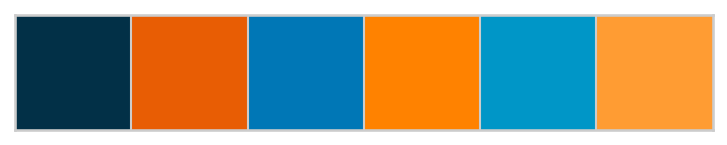

In [3]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Detecção de anomalias
from sklearn.ensemble import IsolationForest

# Exibir gráficos dentro do notebook
%matplotlib inline

# Configuração visual
# ==========================
color_palette = [
    '#023047',
    '#e85d04',
    '#0077b6',
    '#ff8200',
    '#0096c7',
    '#ff9c33'
]

sns.set_theme(
    style='whitegrid',
    palette=color_palette,
    font_scale=1.1
)

plt.rcParams['figure.dpi'] = 150

sns.palplot(color_palette)
plt.show()

# **2. Entendendo os dados** 

O conjunto de dados foi coletado no Kaggle:
https://www.kaggle.com/datasets/mrferozi/loan-data-for-dummy-bank/data

A origem do conjunto de dados é baseada nos dados públicos de empréstimos do Lending Club, que foram adaptados para uso educacional.
O dataset contém informações detalhadas sobre solicitantes de empréstimos, incluindo dados demográficos, financeiros, histórico de crédito e características do empréstimo solicitado.

A variável-alvo **loan_condition_cat** indica se o empréstimo foi **bom(0)** ou **ruim(1)**, permitindo formular um problema de classificação binária voltado para análise de risco de crédito.

Inicialmente, algumas variáveis serão removidas porque **não são importantes em um cenário real** de concessão de empréstimos, **possuem duas representações**, sua forma original e categorizada, ou representam **informações futuras do empréstimo**.

In [6]:
#db = pd.read_csv(r"C:\Users\davic\OneDrive\Documentos\3UnidadeCienciaDados\projeto-unidade-3-concessores-de-emprestimos\databases\loan_final313_mod.csv")
db = pd.read_csv("../databases/loan_final313_mod.csv")
df = db.copy()

# Features a serem removidas.
df.drop(columns=['home_ownership', 'application_type', 'purpose', 'interest_payments', 'loan_condition', 'grade', 'term', 'total_pymnt', "issue_d", 'total_rec_prncp', 'recoveries', 'final_d'], inplace=True)

As variáveis **home_ownership, application_type, purpose, interest_payments, loan_condition, grade e term* foram removidas por possuírem versões categorizadas já presentes no conjunto de dados. Assim, optou-se por manter apenas as **variáveis codificadas** *(_cat)*, evitando redundância de informação.

Já as variáveis *total_pymnt, issue_d, total_rec_prncp, recoveries e final_d* foram removidas por representarem **informações futuras** do empréstimo ou **atributos temporais** que **não estariam disponíveis no momento da concessão do crédito**. A permanência dessas variáveis poderia causar data leakage, permitindo que o modelo aprendesse padrões derivados do desfecho do empréstimo, comprometendo sua capacidade de generalização e tornando a avaliação irrealisticamente otimista.

In [8]:
df.head(10)

,id,year,emp_length_int,home_ownership_cat,income_category,annual_inc,income_cat,loan_amount,term_cat,application_type_cat,purpose_cat,interest_payment_cat,loan_condition_cat,interest_rate,grade_cat,dti,installment,region
0,63398958.0,2015.0,8.0,1.0,Low,78000.0,1.0,NaN,1.0,1.0,8.0,2.0,0.0,15.61,4.0,25.71,279.72,ulster
1,27610673.0,2014.0,3.0,1.0,Low,81700.0,1.0,21000.0,1.0,1.0,6.0,1.0,0.0,10.15,2.0,22.33,679.10,leinster
2,49925091.0,2015.0,10.0,3.0,Low,78000.0,1.0,19725.0,1.0,1.0,6.0,1.0,0.0,7.89,1.0,14.12,617.11,Northern-Irl
3,28102260.0,2014.0,9.0,1.0,Low,35000.0,1.0,8000.0,1.0,1.0,6.0,2.0,0.0,15.61,4.0,32.07,279.72,ulster
4,57324697.0,NaN,10.0,1.0,Low,85000.0,1.0,35000.0,1.0,1.0,6.0,2.0,0.0,NaN,4.0,25.19,1247.68,ulster
5,61402817.0,2015.0,10.0,3.0,Low,100000.0,1.0,24000.0,1.0,1.0,6.0,1.0,0.0,12.29,3.0,6.38,800.48,leinster
6,38700393.0,2015.0,2.0,3.0,Low,95000.0,1.0,28000.0,2.0,1.0,6.0,2.0,0.0,NaN,3.0,16.20,656.02,cannught
7,59955204.0,2015.0,10.0,1.0,Medium,160000.0,2.0,35000.0,1.0,1.0,7.0,1.0,0.0,7.89,1.0,6.70,1095.00,Northern-Irl
8,6156565.0,2013.0,6.0,1.0,Low,78000.0,1.0,35000.0,2.0,1.0,6.0,2.0,0.0,24.89,6.0,28.71,1025.05,Northern-Irl
9,27511428.0,2014.0,3.0,3.0,Low,100000.0,1.0,30000.0,2.0,NaN,6.0,2.0,0.0,16.29,4.0,16.31,734.18,munster


## **Dicionário de dados**

**1.ID:** Identificador único de cada registro de empréstimo. Categórica nominal.

**2.YEAR:** Ano em que o empréstimo foi emitido (derivado da data de emissão). Numérica discreta.

**3.EMP_LENGTH_INT:** Tempo de emprego em anos. Numérica contínua.

**4.HOME_OWNERSHIP_CAT:** Categoria codificada que representa a situação de moradia (ex.: ALUGADO, PRÓPRIA, HIPOTECADA). Categórica ordinal.

**5.INCOME_CATEGORY:** Categoria de renda do tomador (ex.: Baixa, Média, Alta). Categórica nominal.

**6.ANNUAL_INC:** Renda anual do tomador. Numérica contínua.

**7.INCOME_CAT:** Versão codificada da categoria de renda. Categórica ordinal.

**8.LOAN_AMOUNT:** Valor total solicitado do empréstimo. Numérica contínua.

**9.TERM_CAT:** Versão codificada do prazo do empréstimo(36 ou 60 meses). Categórica nominal.

**10.APPLICATION_TYPE_CAT:** Tipo de aplicação codificada (individual ou conjunta). Categórica nominal.

**11.PURPOSE_CAT:** Finalidade codificada do empréstimo (ex.: consolidação de dívidas, médico, carro). Categórica nominal.

**12.INTEREST_PAYMENT_CAT:** Tipo codificado de estrutura de pagamento de juros (ex.: amortizado, apenas juros). Categórica nominal.

**13.LOAN_CONDITION_CAT:** Condição final do empréstimo: 0 = totalmente pago, 1 = inadimplente. Categórica binária.

**14.INTEREST_RATE:** Taxa de juros anual aplicada ao empréstimo. Numérica contínua.

**15.GRADE_CAT:** Categoria codificada da nota de crédito atribuída ao empréstimo (A, B, C...). Categórica ordinal.

**16.DTI:** Relação dívida/renda do tomador. Numérica contínua.

**17.INSTALLMENT:** Valor da parcela mensal do empréstimo. Numérica contínua.

**18.REGION:** Região geográfica onde o tomador reside (províncias da Irlanda: Leinster, Munster, Ulster, Connacht, Irlanda do Norte). Categórica nominal.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7906 non-null   float64
 1   year                  7917 non-null   float64
 2   emp_length_int        7912 non-null   float64
 3   home_ownership_cat    7921 non-null   float64
 4   income_category       7929 non-null   object 
 5   annual_inc            7934 non-null   float64
 6   income_cat            7923 non-null   float64
 7   loan_amount           7281 non-null   float64
 8   term_cat              7912 non-null   float64
 9   application_type_cat  7946 non-null   float64
 10  purpose_cat           7929 non-null   float64
 11  interest_payment_cat  7924 non-null   float64
 12  loan_condition_cat    7921 non-null   float64
 13  interest_rate         7285 non-null   float64
 14  grade_cat             7914 non-null   float64
 15  dti                  

In [11]:
print(f'O dataframe possui {df.shape[0]} linhas e {df.shape[1]} colunas') 

O dataframe possui 8000 linhas e 18 colunas


Olhando as variáveis estatisticas 

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,7906.0,3.261400e+07,2.301002e+07,68817.00,8966704.50,34894352.50,55239855.75,68616891.00
year,7917.0,2.014021e+03,1.259601e+00,2007.00,2013.00,2014.00,2015.00,2015.00
emp_length_int,7912.0,5.917941e+00,3.538755e+00,0.50,3.00,6.05,10.00,10.00
home_ownership_cat,7921.0,2.092665e+00,9.486822e-01,1.00,1.00,3.00,3.00,3.00
annual_inc,7934.0,7.411045e+04,4.682275e+04,5000.00,45000.00,64942.00,90000.00,1036000.00
income_cat,7923.0,1.194623e+00,4.357032e-01,1.00,1.00,1.00,1.00,3.00
loan_amount,7281.0,1.466940e+04,8.383141e+03,1000.00,8000.00,13000.00,20000.00,35000.00
term_cat,7912.0,1.302578e+00,4.594033e-01,1.00,1.00,1.00,2.00,2.00
application_type_cat,7946.0,1.000503e+00,2.243229e-02,1.00,1.00,1.00,1.00,2.00
purpose_cat,7929.0,4.862908e+00,2.392702e+00,1.00,3.00,6.00,6.00,13.00


algumas conluções:
1. A maioria dos empréstimos ocorreu entre 2013 e 2015, indicando uma base relativamente recente e concentrada.
2. Os empréstimos são, em geral, de pequeno a médio porte, tendo uma média de 13 mil.
3. A maioria dos empréstimos é de 36 meses, com uma parte menor de 60 meses.
4. Níveis médios de juros, entre os 13%.
5. Clientes têm nível moderado de comprometimento da renda, cerca de 18%, dentro do aceitável.

Convertendo os formatos das colunas

In [16]:
cat_num_cols = [
    "home_ownership_cat",
    "term_cat",
    "grade_cat",
    "interest_payment_cat",
    "application_type_cat",
    "purpose_cat",
    "income_cat"
]

for col in cat_num_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

Olhando se há valores faltantes ou duplicados

In [18]:
df.isna().sum()

id                       94
year                     83
emp_length_int           88
home_ownership_cat       79
income_category          71
annual_inc               66
income_cat               77
loan_amount             719
term_cat                 88
application_type_cat     54
purpose_cat              71
interest_payment_cat     76
loan_condition_cat       79
interest_rate           715
grade_cat                86
dti                      79
installment              81
region                   82
dtype: int64

Analisando a porcentagem em cada coluna

In [20]:
for coluna in df.columns:
    nulos = df[coluna].isnull().sum()
    total = len(df)
    percentual = (nulos / total) * 100
    print(f"A coluna {coluna} tem {percentual:.1f}% de nulos ({nulos}/{total})")

A coluna id tem 1.2% de nulos (94/8000)
A coluna year tem 1.0% de nulos (83/8000)
A coluna emp_length_int tem 1.1% de nulos (88/8000)
A coluna home_ownership_cat tem 1.0% de nulos (79/8000)
A coluna income_category tem 0.9% de nulos (71/8000)
A coluna annual_inc tem 0.8% de nulos (66/8000)
A coluna income_cat tem 1.0% de nulos (77/8000)
A coluna loan_amount tem 9.0% de nulos (719/8000)
A coluna term_cat tem 1.1% de nulos (88/8000)
A coluna application_type_cat tem 0.7% de nulos (54/8000)
A coluna purpose_cat tem 0.9% de nulos (71/8000)
A coluna interest_payment_cat tem 0.9% de nulos (76/8000)
A coluna loan_condition_cat tem 1.0% de nulos (79/8000)
A coluna interest_rate tem 8.9% de nulos (715/8000)
A coluna grade_cat tem 1.1% de nulos (86/8000)
A coluna dti tem 1.0% de nulos (79/8000)
A coluna installment tem 1.0% de nulos (81/8000)
A coluna region tem 1.0% de nulos (82/8000)


In [21]:
df.duplicated().sum()

0

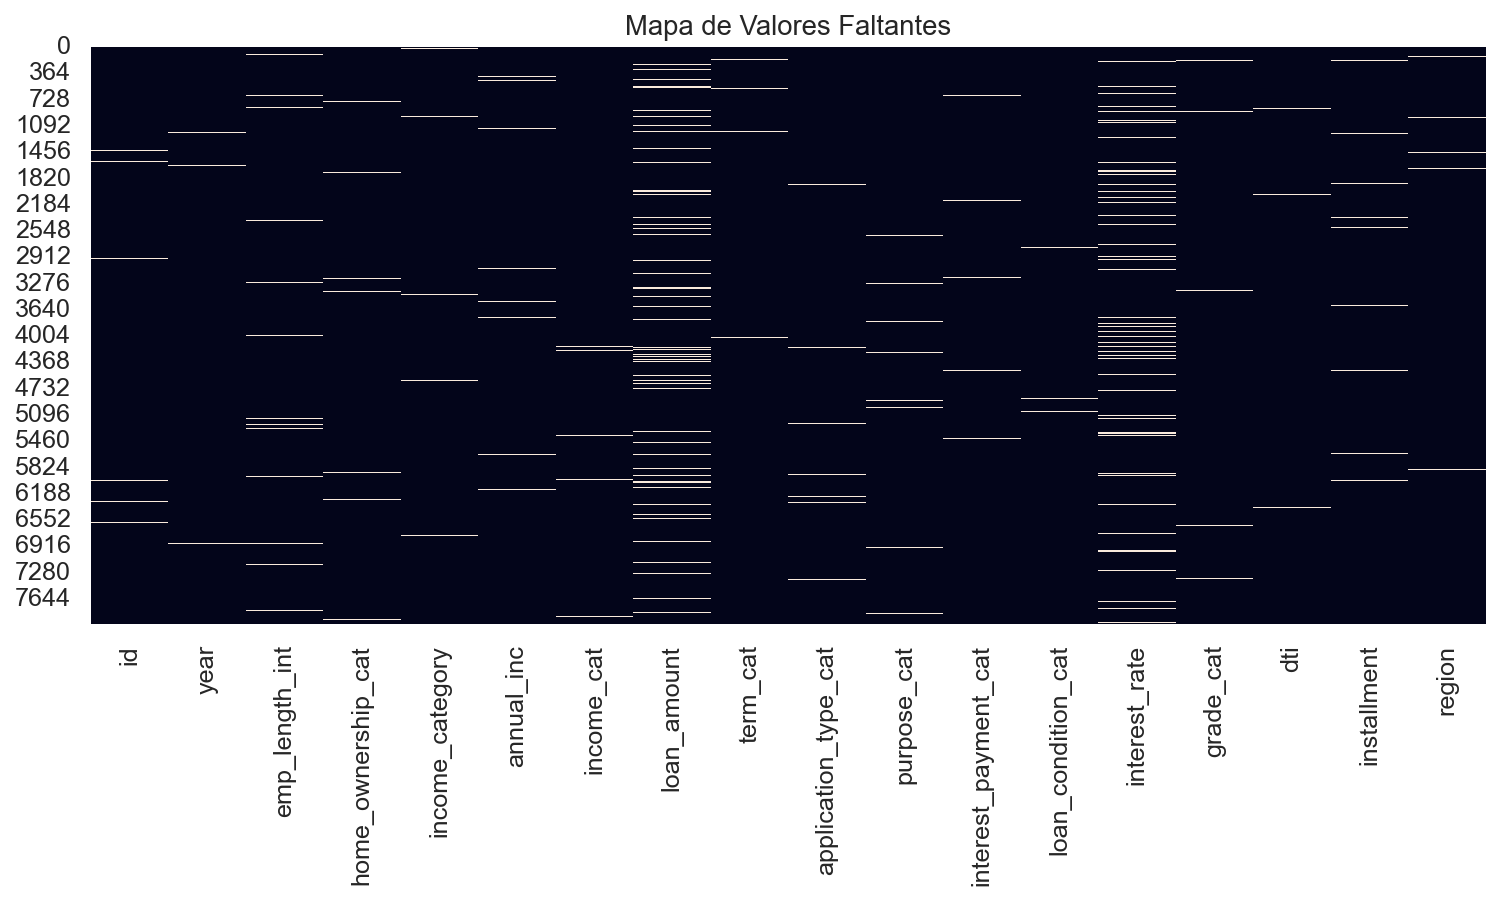

In [24]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de Valores Faltantes")
plt.show()

Não há nenhum valor duplicado, entretanto, todas as features possuem até 10% de valores faltantes.

A feature *ID* será removida por representar apenas um identificador único dos registros, não possuindo relevância preditiva para o modelo.

Além disso, o tratamento de valores faltantes será realizado inicialmente apenas na variável alvo *loan_condition_cat*, removendo-se as linhas que possuem valores nulos nessa coluna. Esse procedimento é necessário porque a variável target é indispensável para o treinamento supervisionado e para a estratificação da divisão entre treino e teste (stratify=y), que não aceita valores ausentes.

As demais variáveis terão seus valores faltantes tratados posteriormente, após a divisão da base em conjuntos de treino e teste

In [35]:
df.drop(columns=['id'], inplace=True)
df = df.dropna(subset=['loan_condition_cat']).copy()

verificando a remoção:

In [38]:
df.loan_condition_cat.isna().sum()

0

# **3. Dividindo a base em treino e teste**

Primeiramente, dividirei os dados em conjuntos de treino e teste.
O conjunto de teste deve conter dados que o modelo nunca tenha visto antes.

Realizarei a Análise Exploratória dos Dados (EDA) focando apenas no conjunto de treinamento, com o objetivo de evitar vazamento de dados (data leakage), obter uma representação realista do problema e avaliar corretamente o modelo com dados realmente inéditos.

In [42]:
X = df.drop(columns=['loan_condition_cat'])
y = df['loan_condition_cat'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [44]:
print(f'Tamanho do conjunto de preditores de treino: {X_train.shape}.')
print(f'Tamanho do conjunto alvo de treino: {y_train.shape}.')
print(f'Tamanho do conjunto de preditores de teste: {X_test.shape}.')
print(f'Tamanho do conjunto alvo de teste: {y_test.shape}.')

Tamanho do conjunto de preditores de treino: (6336, 16).
Tamanho do conjunto alvo de treino: (6336,).
Tamanho do conjunto de preditores de teste: (1585, 16).
Tamanho do conjunto alvo de teste: (1585,).


# **4. Análise exploratória de dados**

Explorarei o conjunto de treinamento para obter uma melhor compreensão de como as variáveis são distribuídas individualmente, dos relacionamentos entre elas, das correlações, tendências e possíveis insights provenientes dos dados, especialmente no que diz respeito à variável alvo. Assim, realizarei análises.

In [48]:
train = pd.concat([X_train, y_train], axis=1)

In [50]:
numericas = train.select_dtypes(include=['float64', 'int64'])
categoricas = train.select_dtypes(include=['object','category'])

In [52]:
numericas.columns

Index(['year', 'emp_length_int', 'annual_inc', 'loan_amount', 'interest_rate',
       'dti', 'installment', 'loan_condition_cat'],
      dtype='object')

In [54]:
categoricas.columns

Index(['home_ownership_cat', 'income_category', 'income_cat', 'term_cat',
       'application_type_cat', 'purpose_cat', 'interest_payment_cat',
       'grade_cat', 'region'],
      dtype='object')

In [58]:
inadimplencia_ano = train.groupby('year')['loan_condition_cat'].mean()
print(inadimplencia_ano)

year
2007.0    0.250000
2008.0    0.166667
2009.0    0.096774
2010.0    0.136364
2011.0    0.172840
2012.0    0.171831
2013.0    0.126233
2014.0    0.098852
2015.0    0.029974
Name: loan_condition_cat, dtype: float64


Ao analisar a variação das taxas de inadimplência ao longo dos anos, observa-se uma tendência de redução desde 2007, o que pode indicar a adoção de melhores políticas de concessão de crédito e gestão de risco ao longo do período.

## Distribuições da variável alvo

In [79]:
train['loan_condition_cat'].value_counts(normalize=True)

loan_condition_cat
0.0    0.923138
1.0    0.076862
Name: proportion, dtype: float64

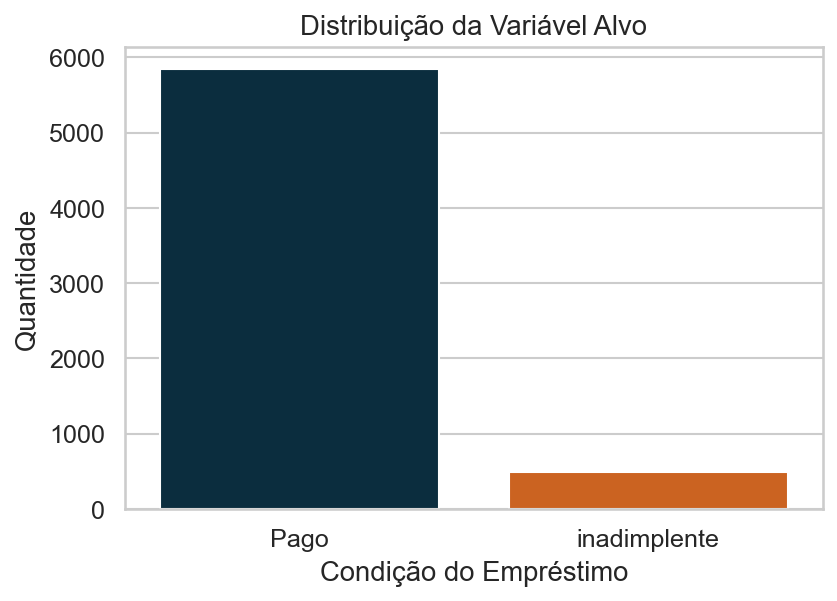

In [86]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x='loan_condition_cat',
    hue='loan_condition_cat',
    legend=False
)

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Condição do Empréstimo')
plt.ylabel('Quantidade')

plt.xticks([0,1], ['Pago', 'inadimplente'])

plt.show()

Observa-se um forte desbalanceamento entre as classes, o que pode levar modelos a favorecerem a classe majoritária. Portanto, técnicas como ponderação de classes (class_weight) ou métodos de balanceamento, como SMOTE, poderão ser avaliadas durante a etapa de modelagem.

## Análise bivariada com variável alvo

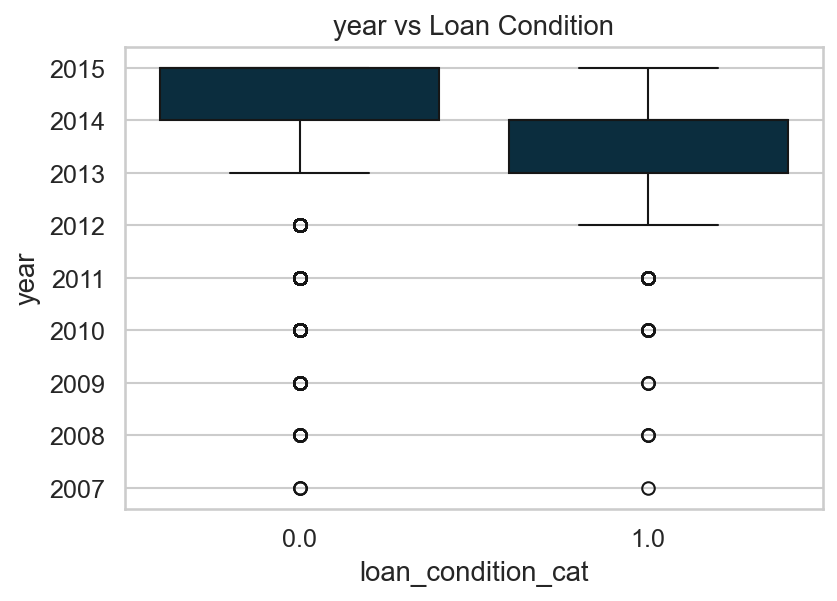

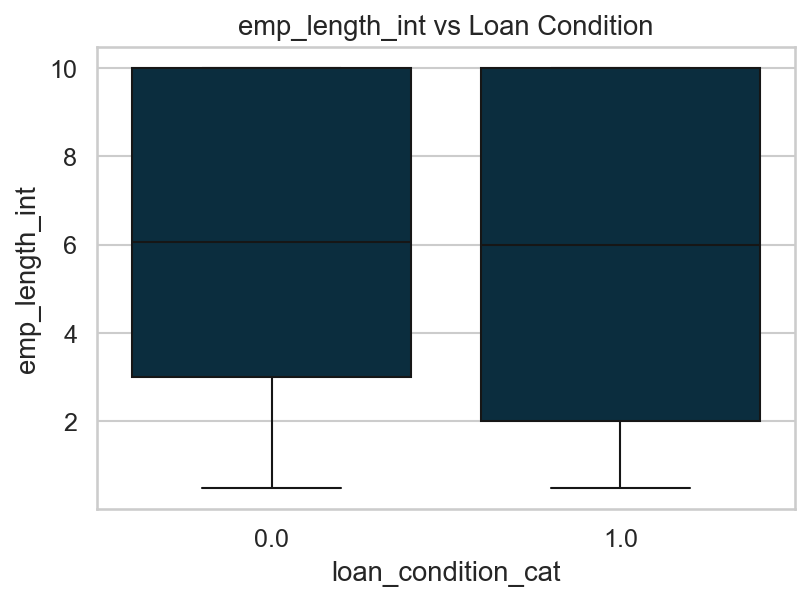

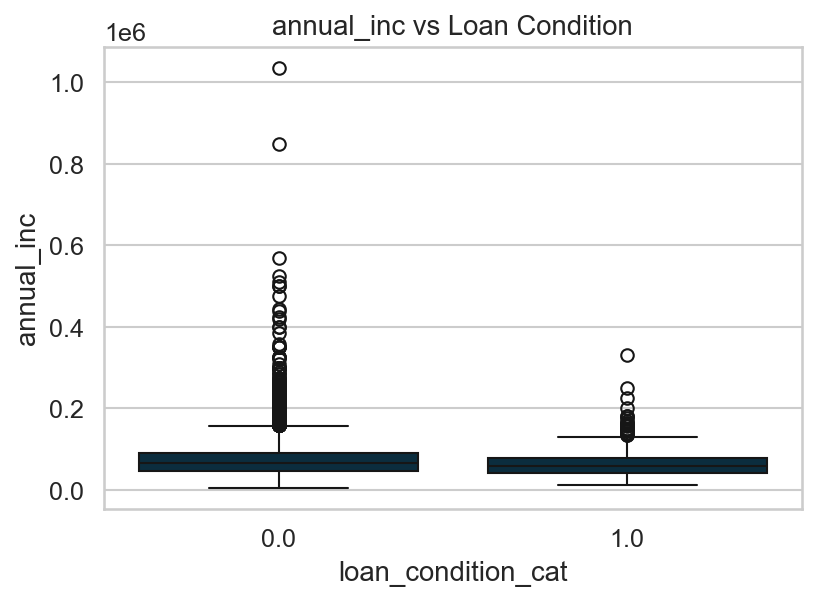

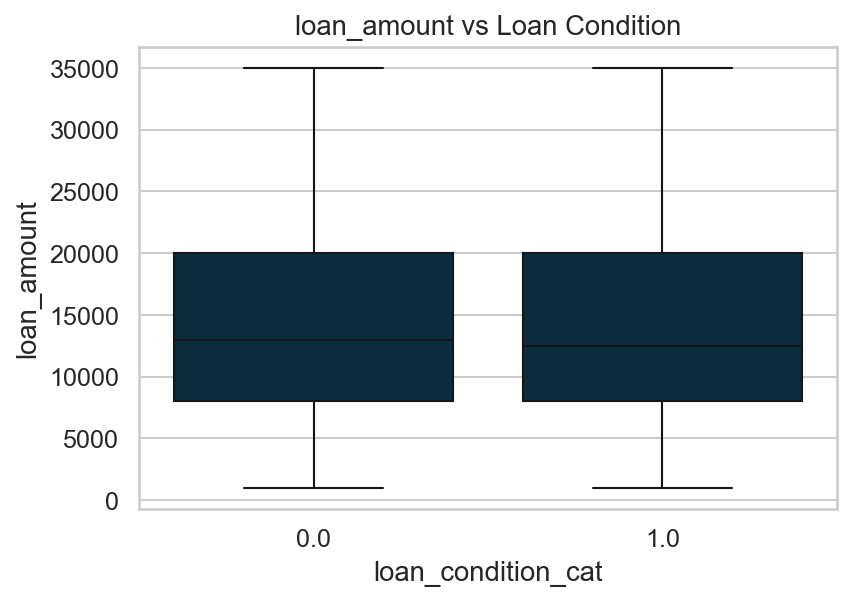

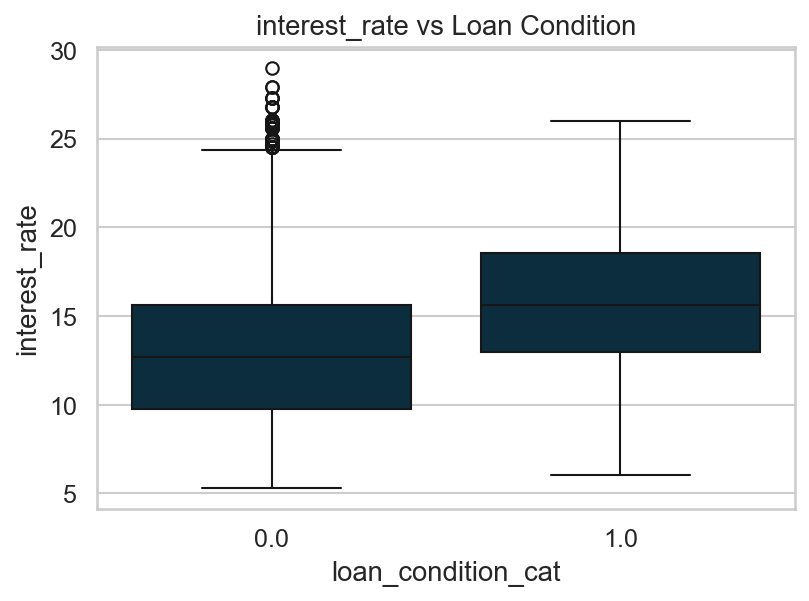

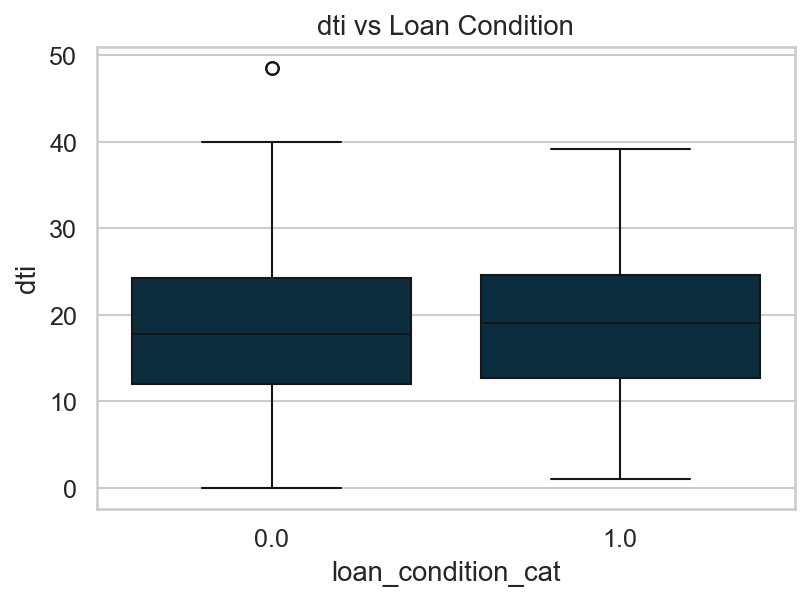

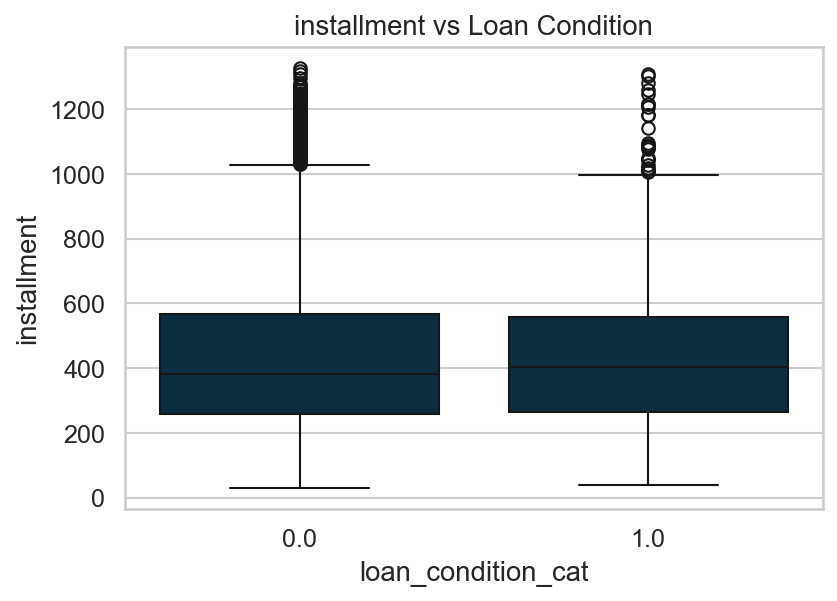

In [90]:
for col in numericas.columns:
    if col != 'loan_condition_cat':  
        plt.figure(figsize=(6,4))
        
        sns.boxplot(
            data=train,
            x='loan_condition_cat',
            y=col
        )
        
        plt.title(f'{col} vs Loan Condition')
        plt.show()

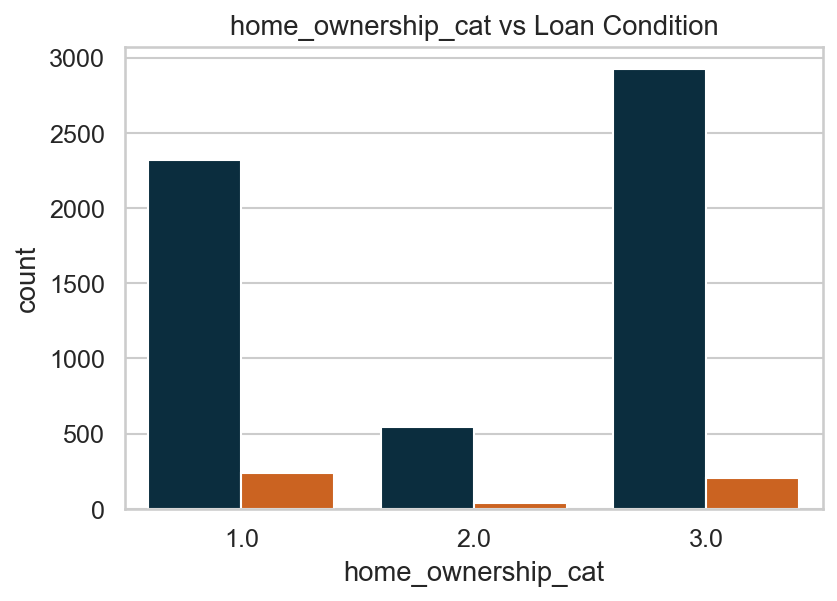

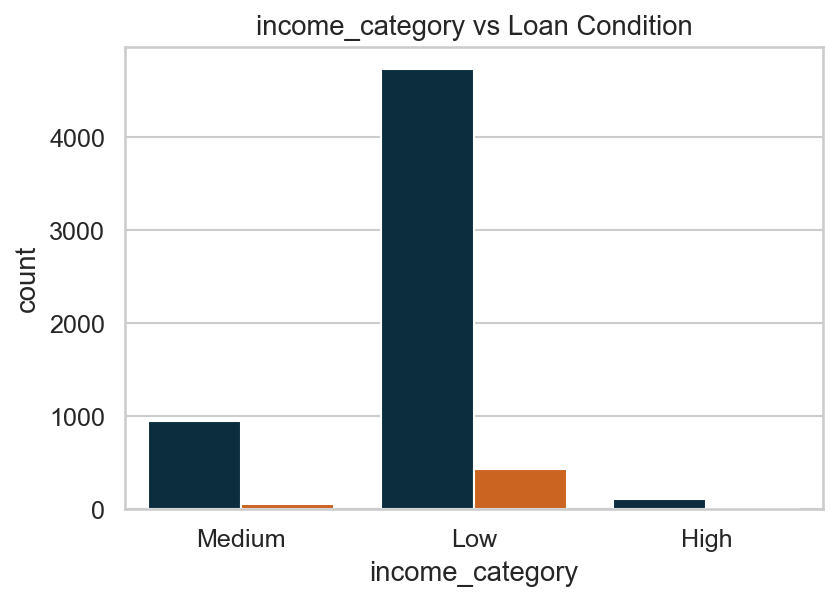

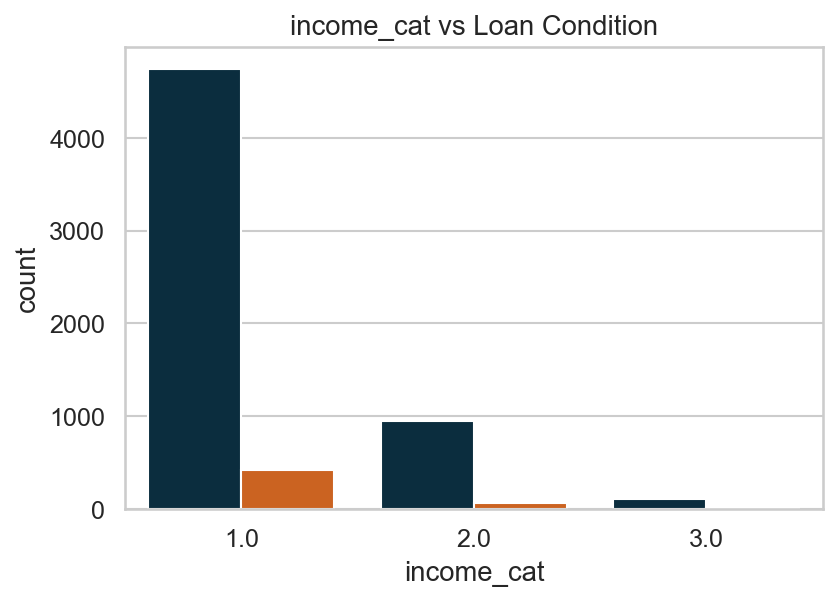

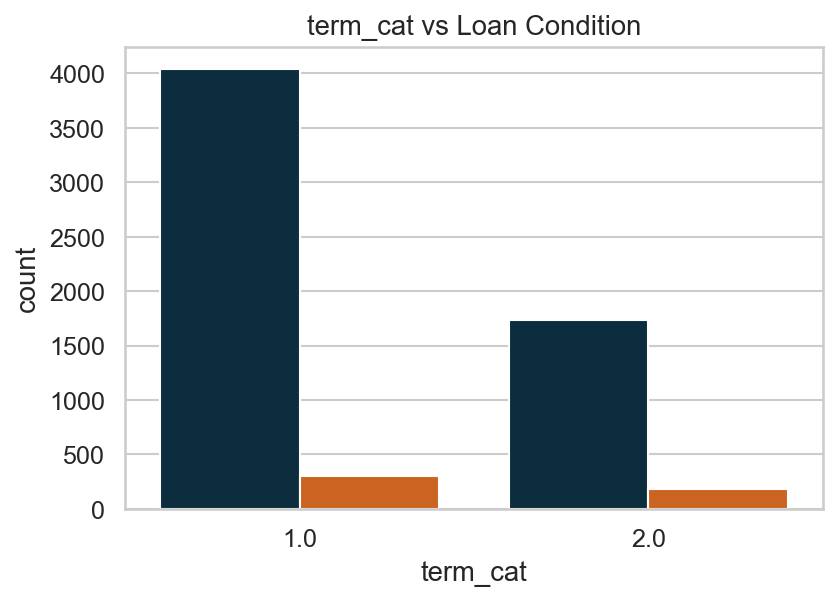

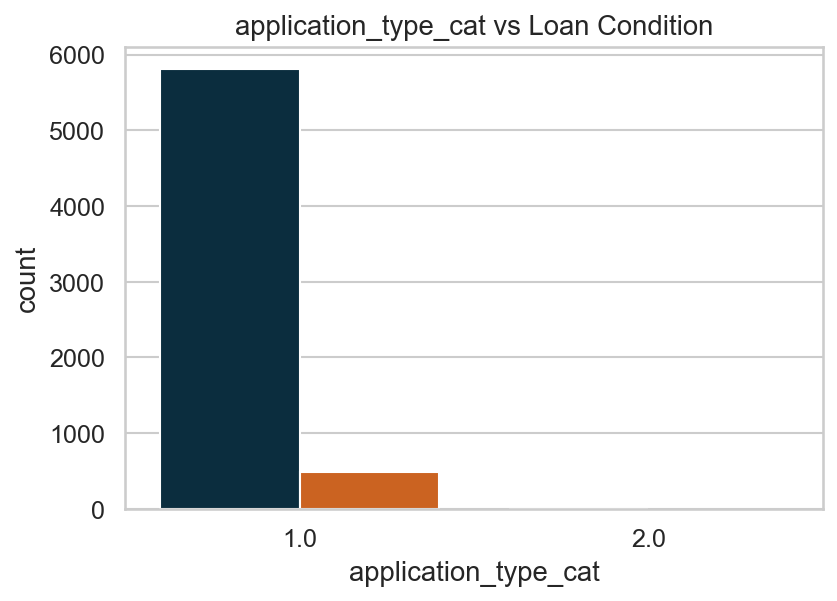

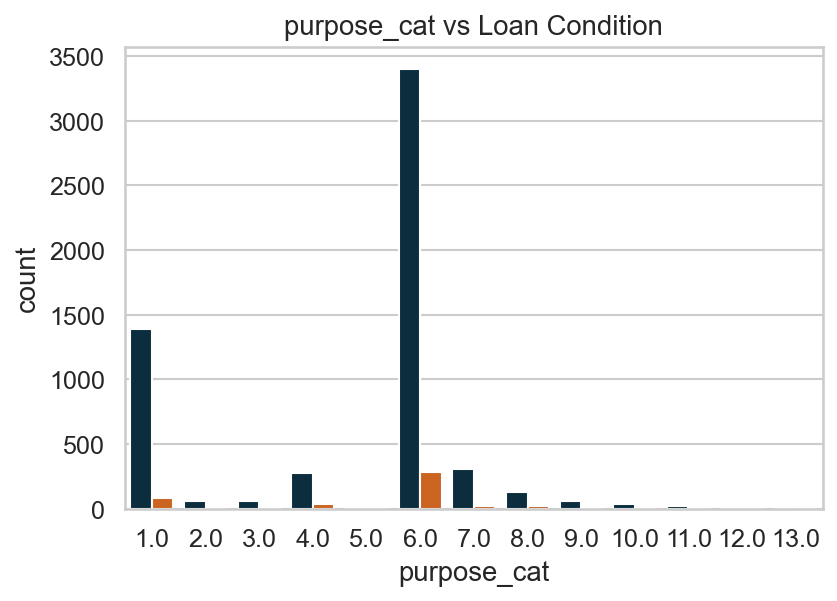

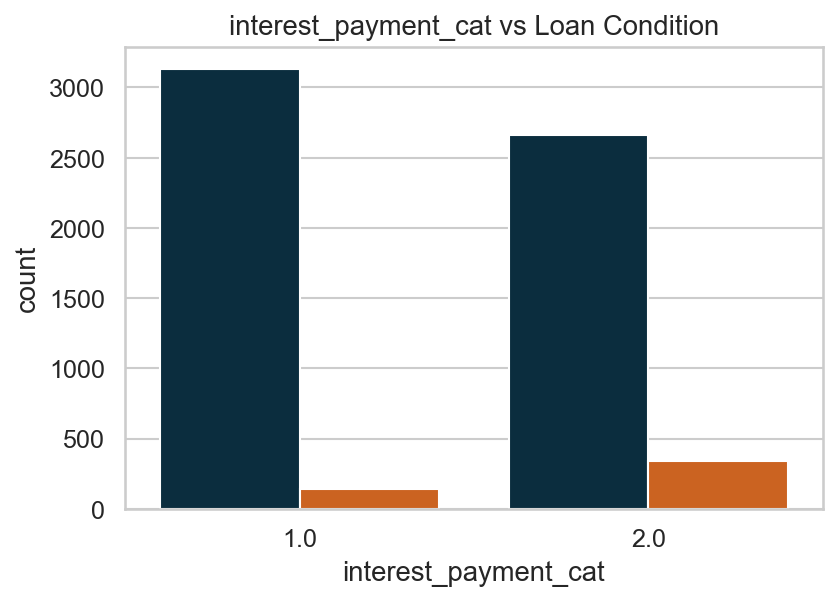

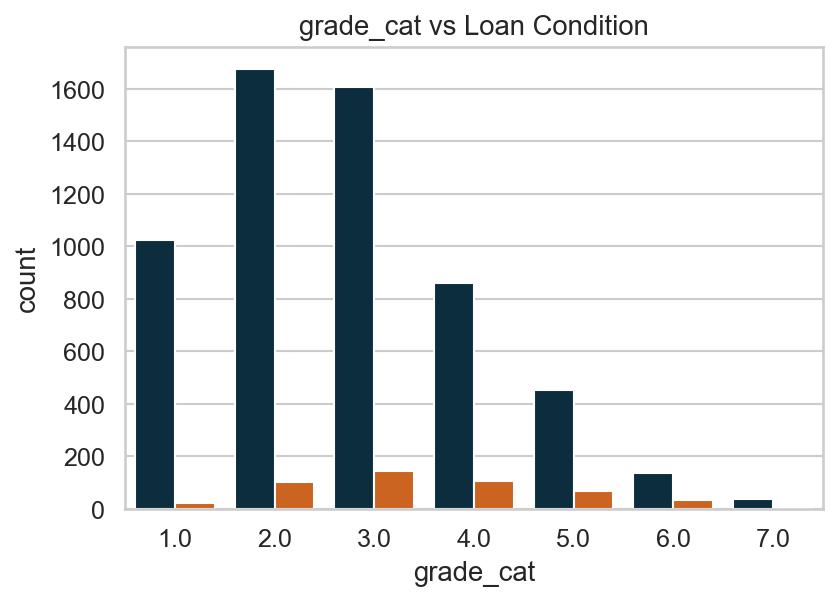

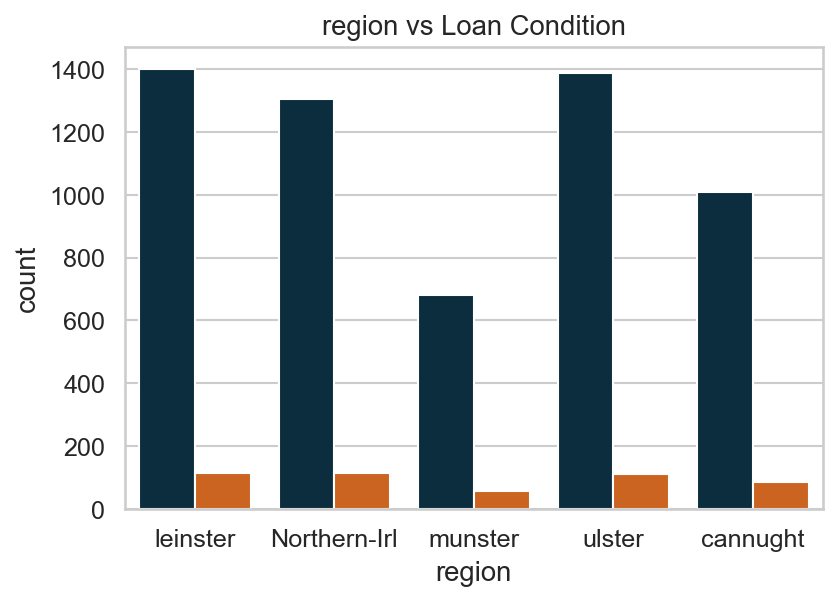

In [92]:
for col in categoricas.columns:
    if col != 'loan_condition_cat':  
        plt.figure(figsize=(6,4))
        
        sns.countplot(
        data=train,
        x=col,
        hue='loan_condition_cat',
        legend=False
        )
        
        plt.title(f'{col} vs Loan Condition')
        plt.show()

A análise bivariada indica que nenhuma variável isoladamente separa completamente bons e maus pagadores. Entretanto, a taxa de juros apresenta comportamento consistente com precificação de risco, sugerindo que o banco já incorpora risco no modelo de concessão. Variáveis como renda, valor do empréstimo e DTI apresentam forte sobreposição entre as classes, indicando que o risco de inadimplência depende de interações não lineares entre múltiplas variáveis.

## Distribuições de características numéricas

Analisarei a seguir a distribuição das características numéricas para verificar se existem distribuições assimétricas e quais são os valores mais comuns para os atributos numéricos dos clientes do banco.

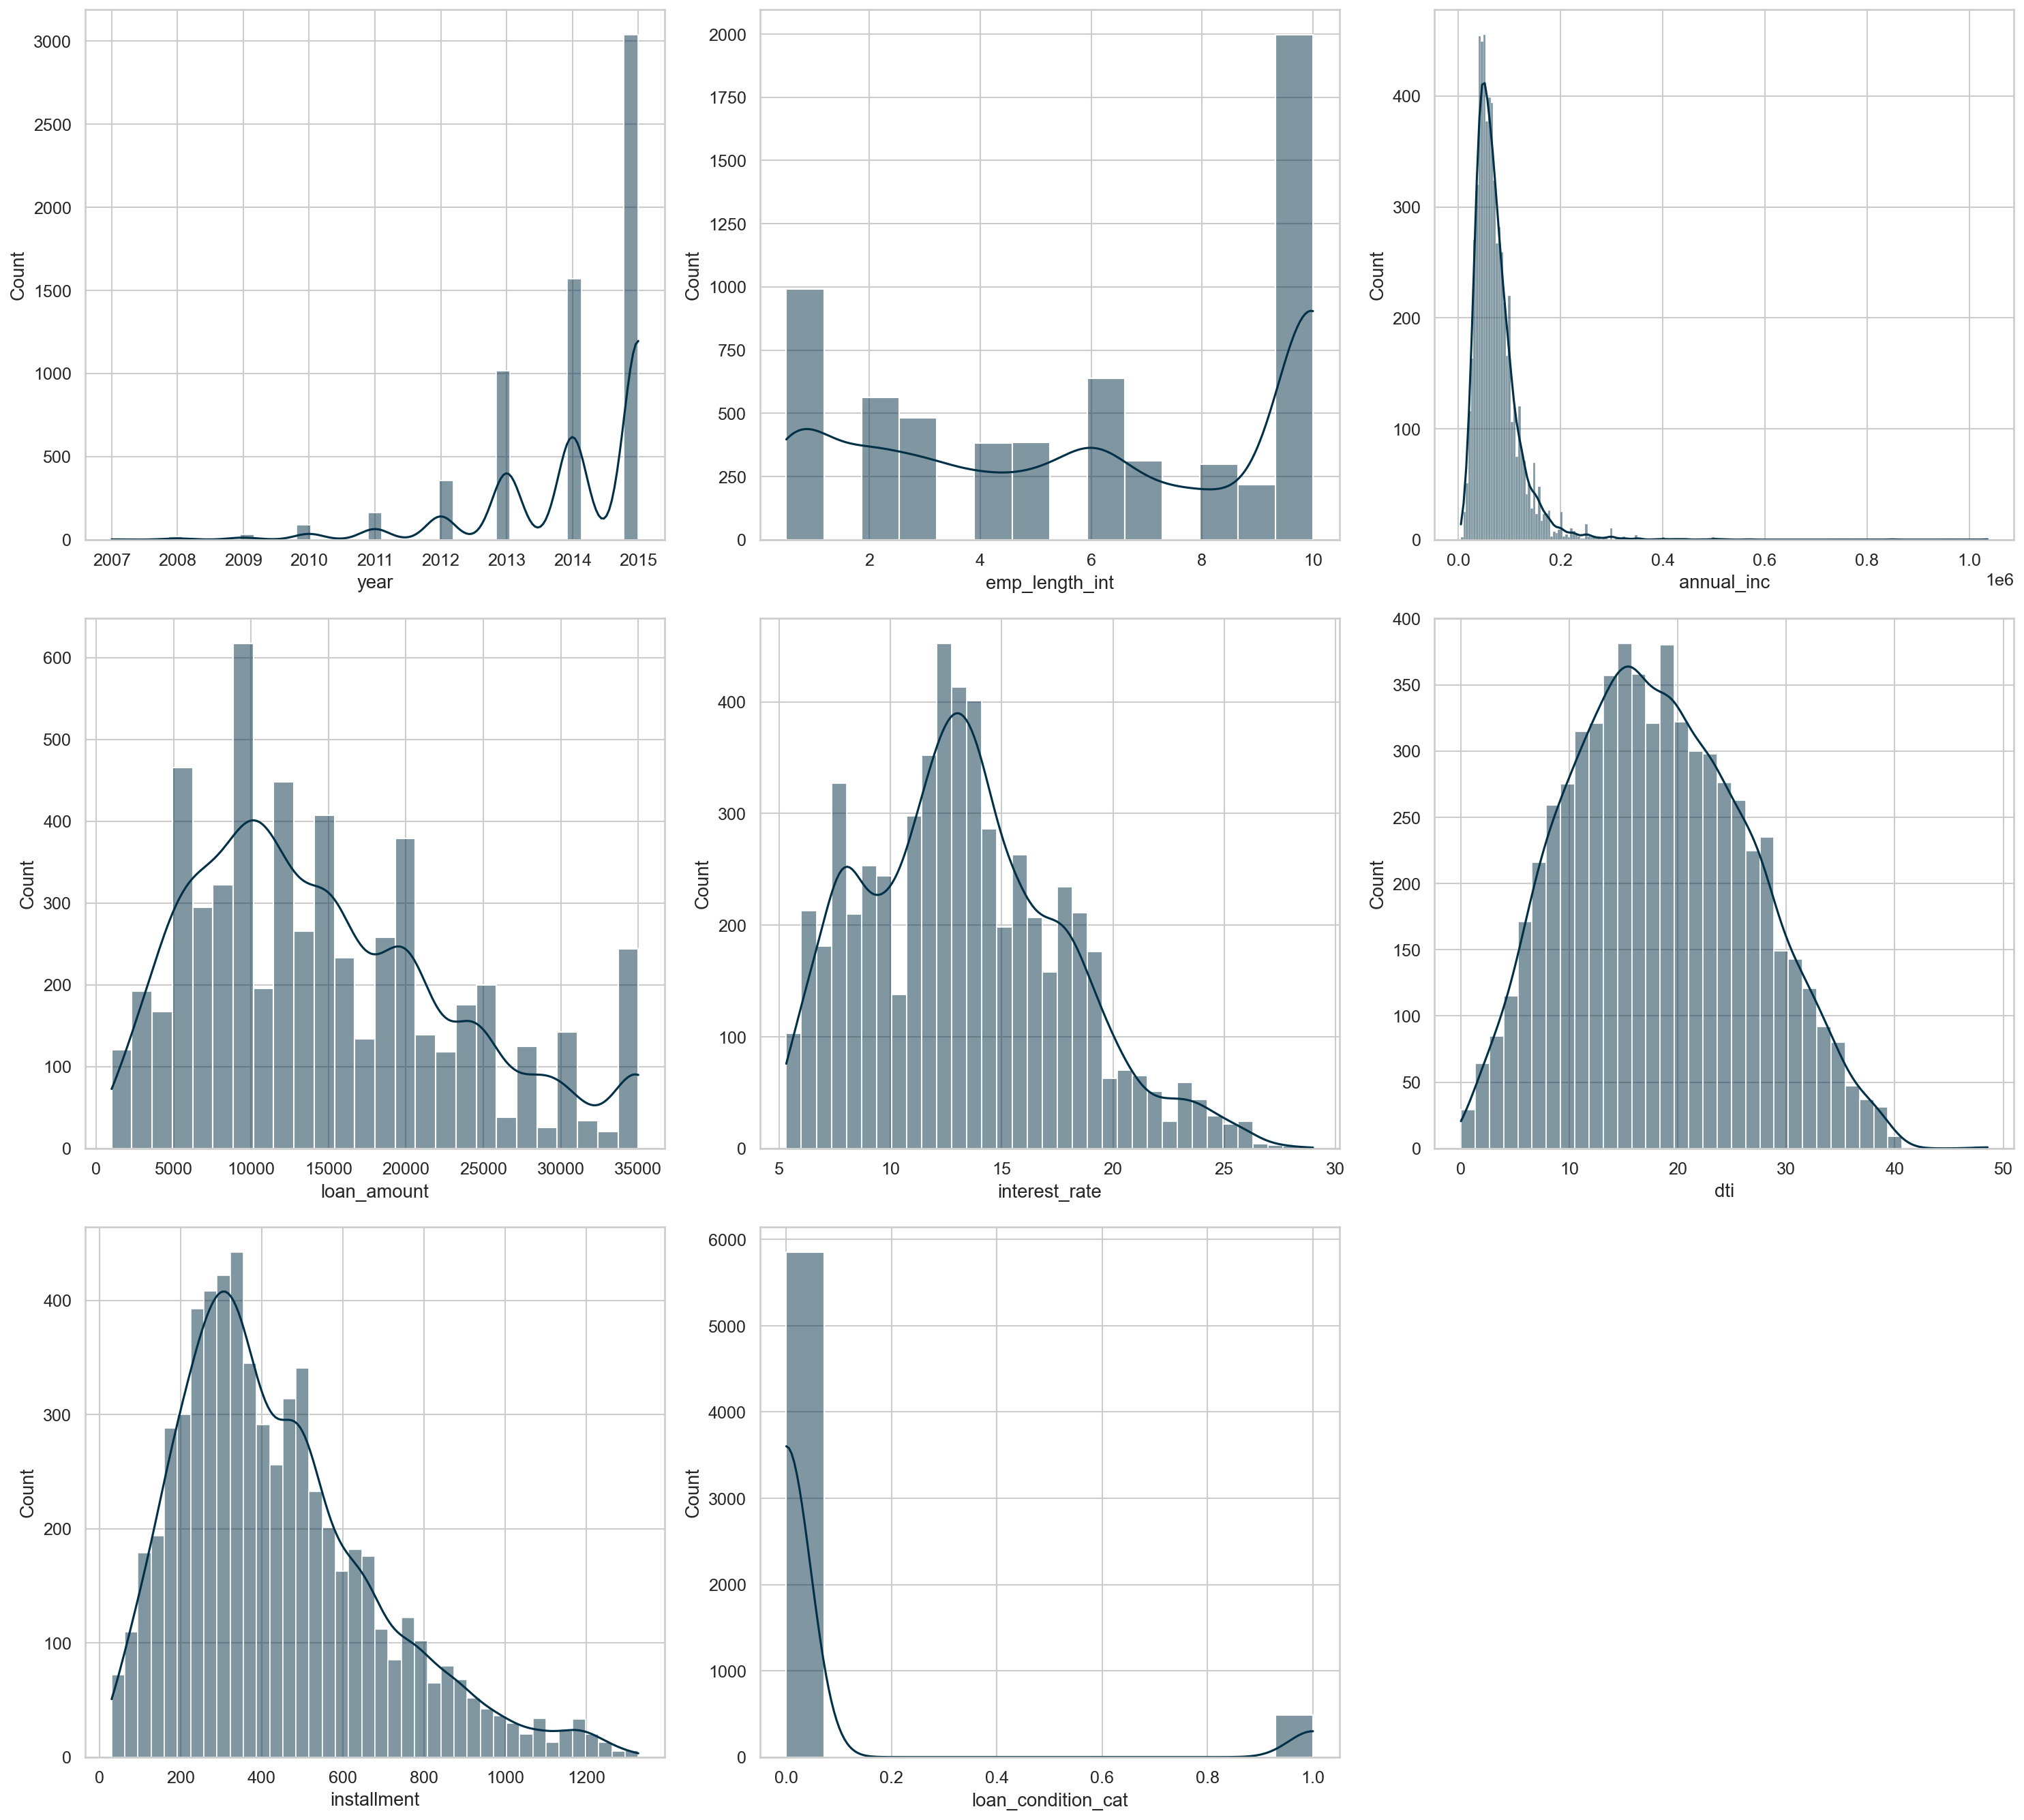

In [94]:
fig, ax = plt.subplots(3, 3, figsize=(20, 18))
ax = ax.flatten()

for i, col in enumerate(numericas.columns):
    sns.histplot(
        numericas[col],
        kde=True,
        ax=ax[i]
    )

for j in range(len(numericas.columns), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

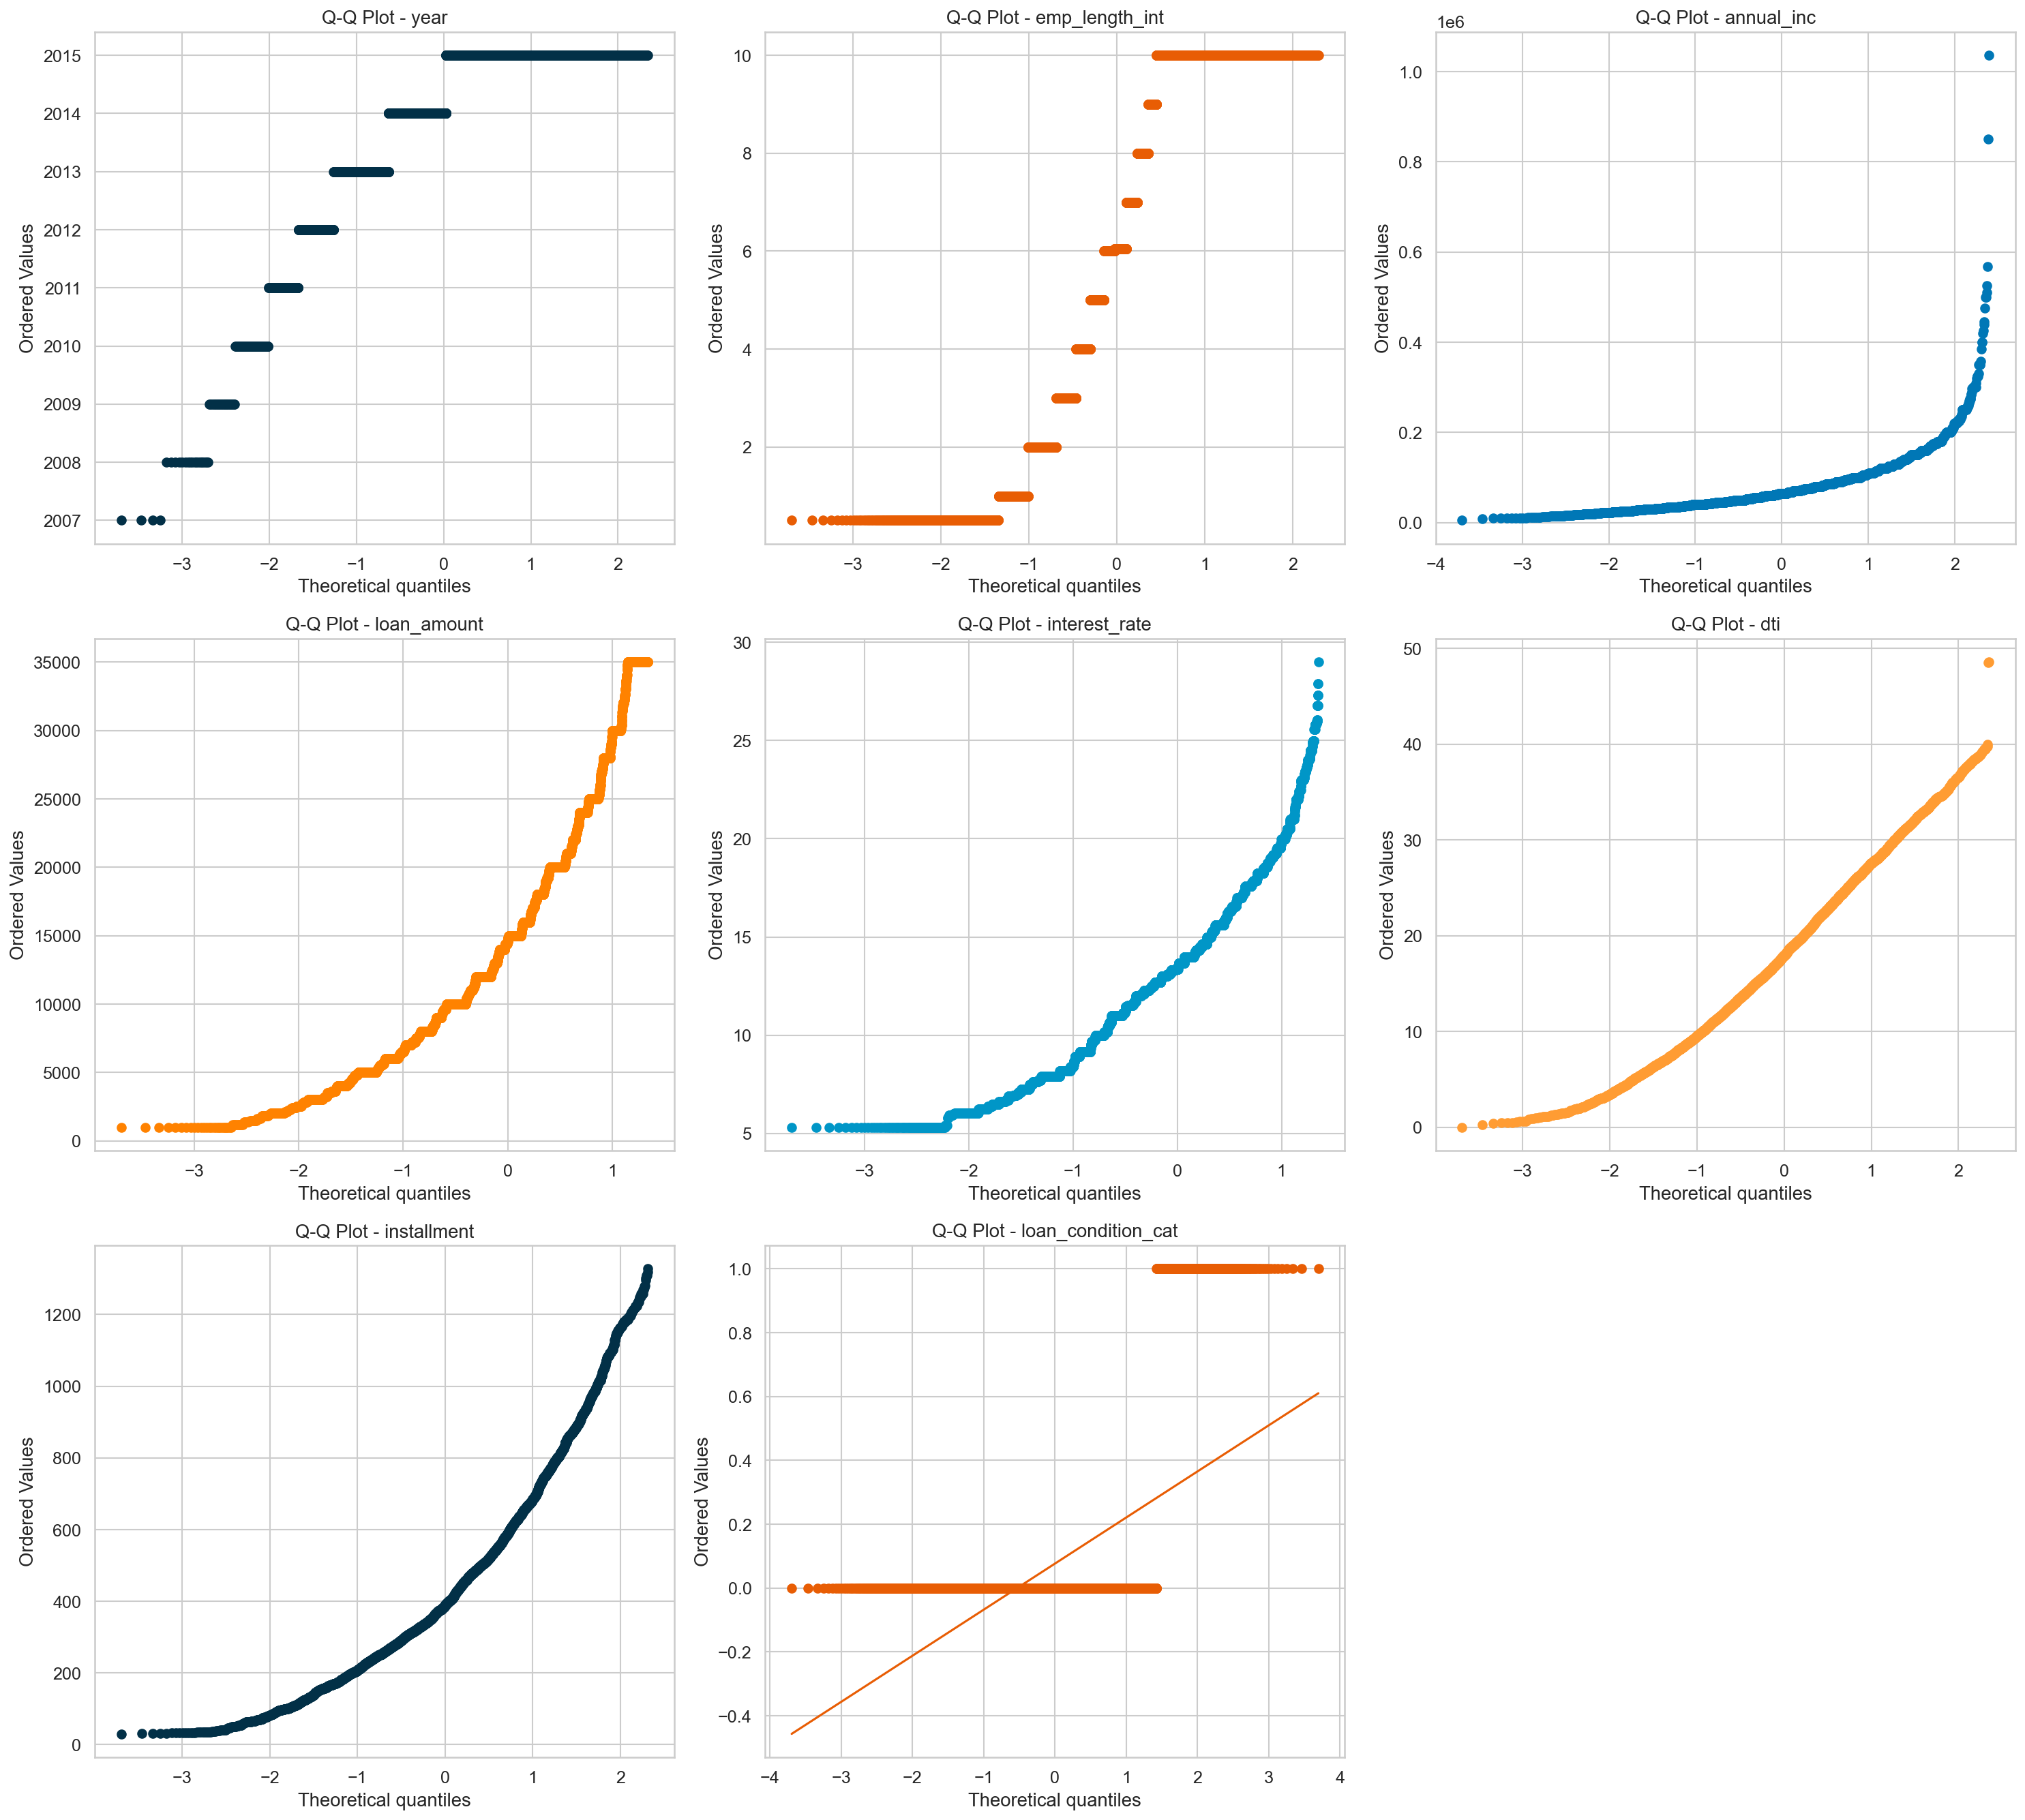

In [96]:
fig, ax = plt.subplots(3, 3, figsize=(20, 18))
ax = ax.flatten()

for i in range(len(numericas.columns)):
    stats.probplot(numericas[numericas.columns[i]], dist="norm", plot=ax[i])

    for line in ax[i].get_lines():
        line.set_color(color_palette[i % len(color_palette)])

    ax[i].set_title(f"Q-Q Plot - {numericas.columns[i]}")

fig.delaxes(ax[len(numericas.columns)])

plt.tight_layout()
plt.show()

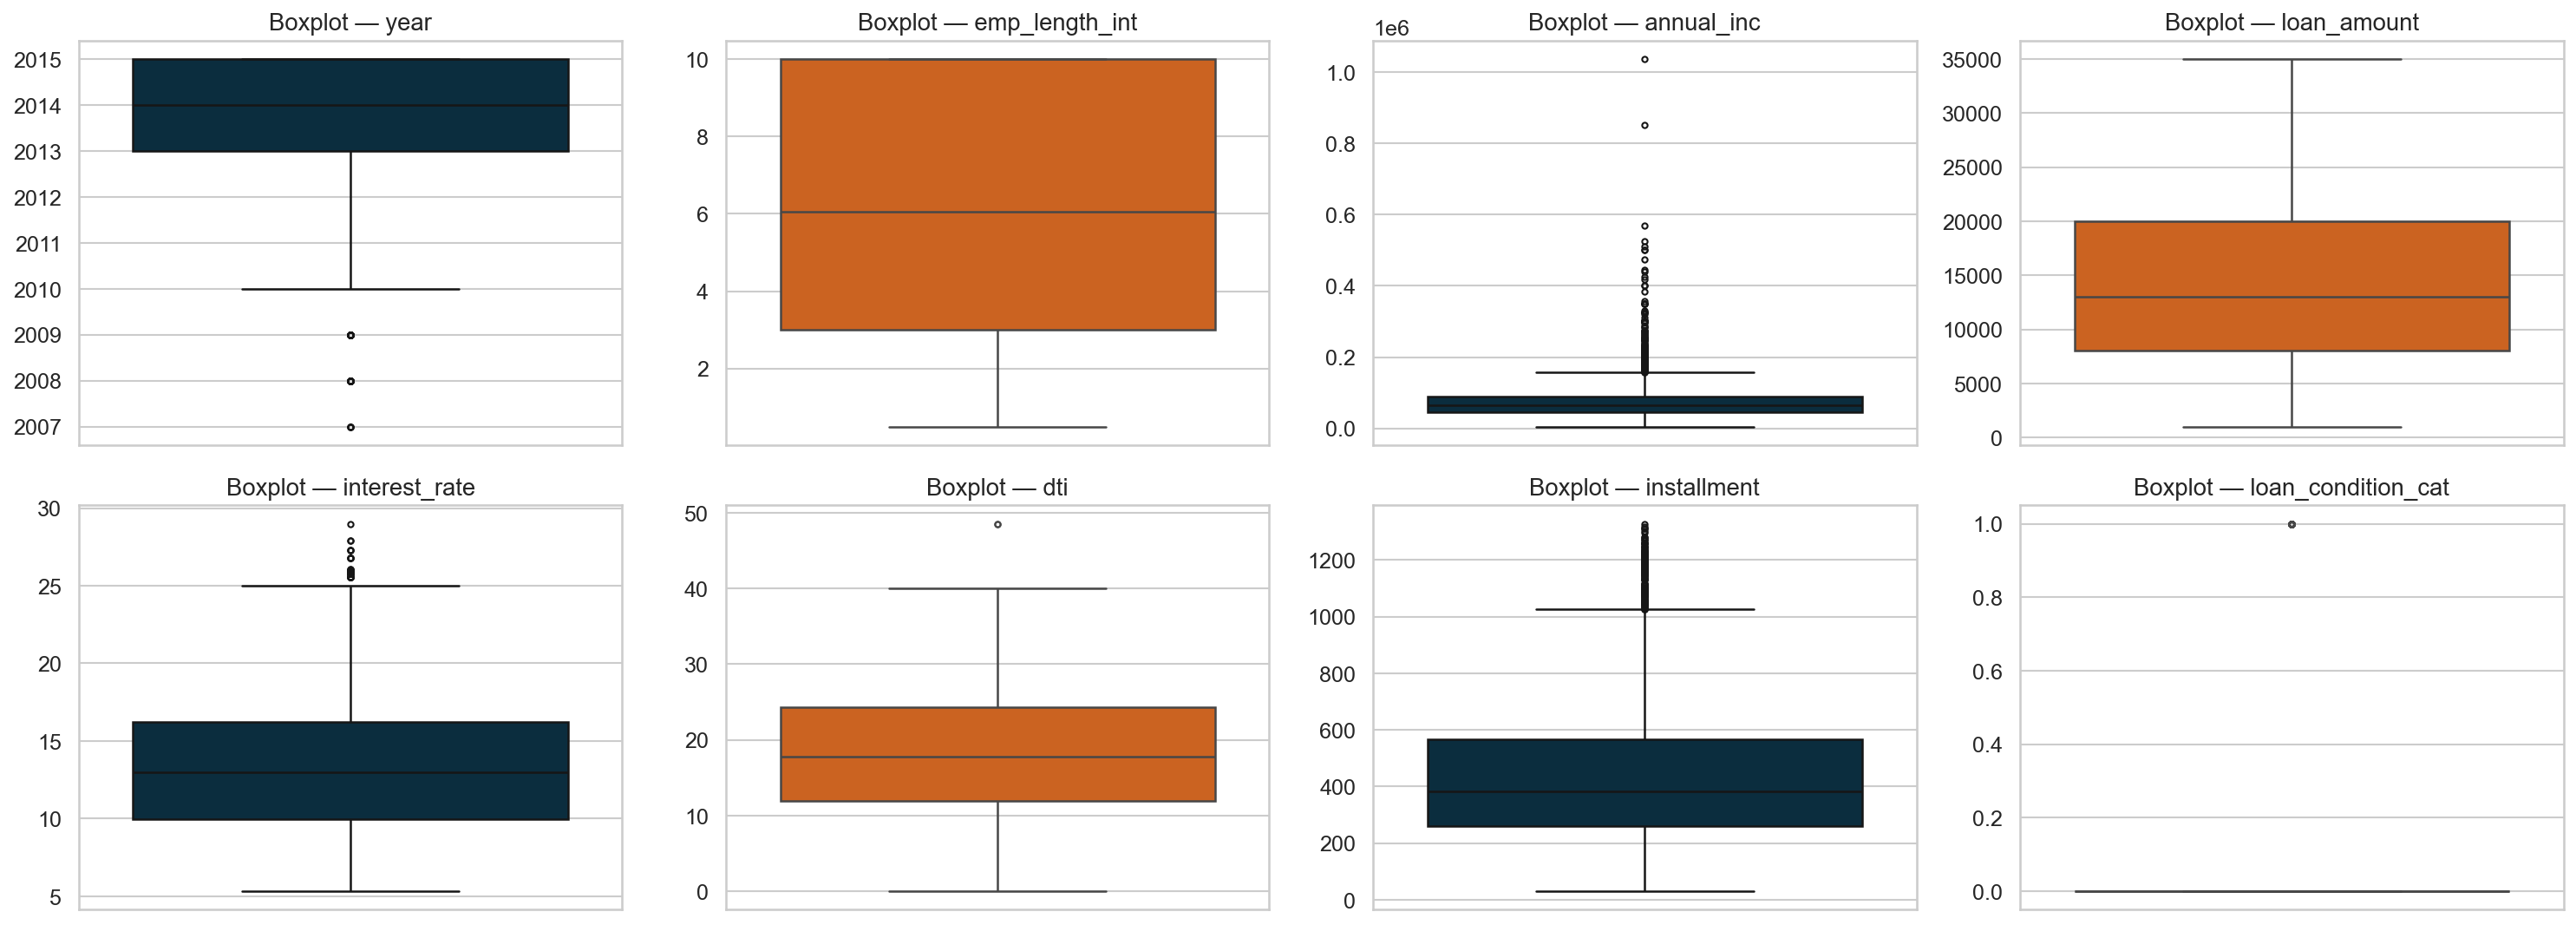

In [97]:
fig, ax = plt.subplots(5, 4, figsize=(20, 18))
ax = ax.flatten()

for i, col in enumerate(numericas.columns):

    sns.boxplot(
        y=numericas[col],
        ax=ax[i],
        color=color_palette[i % 2],   
        fliersize=3,
        linewidth=1.2
    )

    ax[i].set_title(f"Boxplot — {col}")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")

for j in range(len(numericas.columns), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

A análise das distribuições foi realizada por meio de histogramas, Q-Q plots e boxplots. Verificou-se que nenhuma das variáveis numéricas segue distribuição normal. A maioria apresenta assimetria positiva acentuada. O Q-Q plot confirma a ausência de alinhamento com a distribuição normal teórica, reforçando a não-normalidade. Os boxplots também evidenciam distribuições assimétricas, coerentes com os demais gráficos exploratórios

In [174]:
numericas.corr()

,year,emp_length_int,annual_inc,loan_amount,interest_rate,dti,installment,loan_condition_cat
year,1.000000,0.047567,0.035354,0.088651,-0.077137,0.151880,0.057120,-0.163988
emp_length_int,0.047567,1.000000,0.083143,0.126041,0.014417,0.048554,0.110970,-0.011712
annual_inc,0.035354,0.083143,1.000000,0.461752,-0.106919,-0.208861,0.448130,-0.058270
loan_amount,0.088651,0.126041,0.461752,1.000000,0.131596,0.050571,0.944838,-0.000168
interest_rate,-0.077137,0.014417,-0.106919,0.131596,1.000000,0.164104,0.120106,0.170568
dti,0.151880,0.048554,-0.208861,0.050571,0.164104,1.000000,0.035028,0.016902
installment,0.057120,0.110970,0.448130,0.944838,0.120106,0.035028,1.000000,0.008927
loan_condition_cat,-0.163988,-0.011712,-0.058270,-0.000168,0.170568,0.016902,0.008927,1.000000


In [176]:
numericas.corr()["loan_condition_cat"].drop("loan_condition_cat").sort_values(ascending=False)

interest_rate     0.170568
dti               0.016902
installment       0.008927
loan_amount      -0.000168
emp_length_int   -0.011712
annual_inc       -0.058270
year             -0.163988
Name: loan_condition_cat, dtype: float64

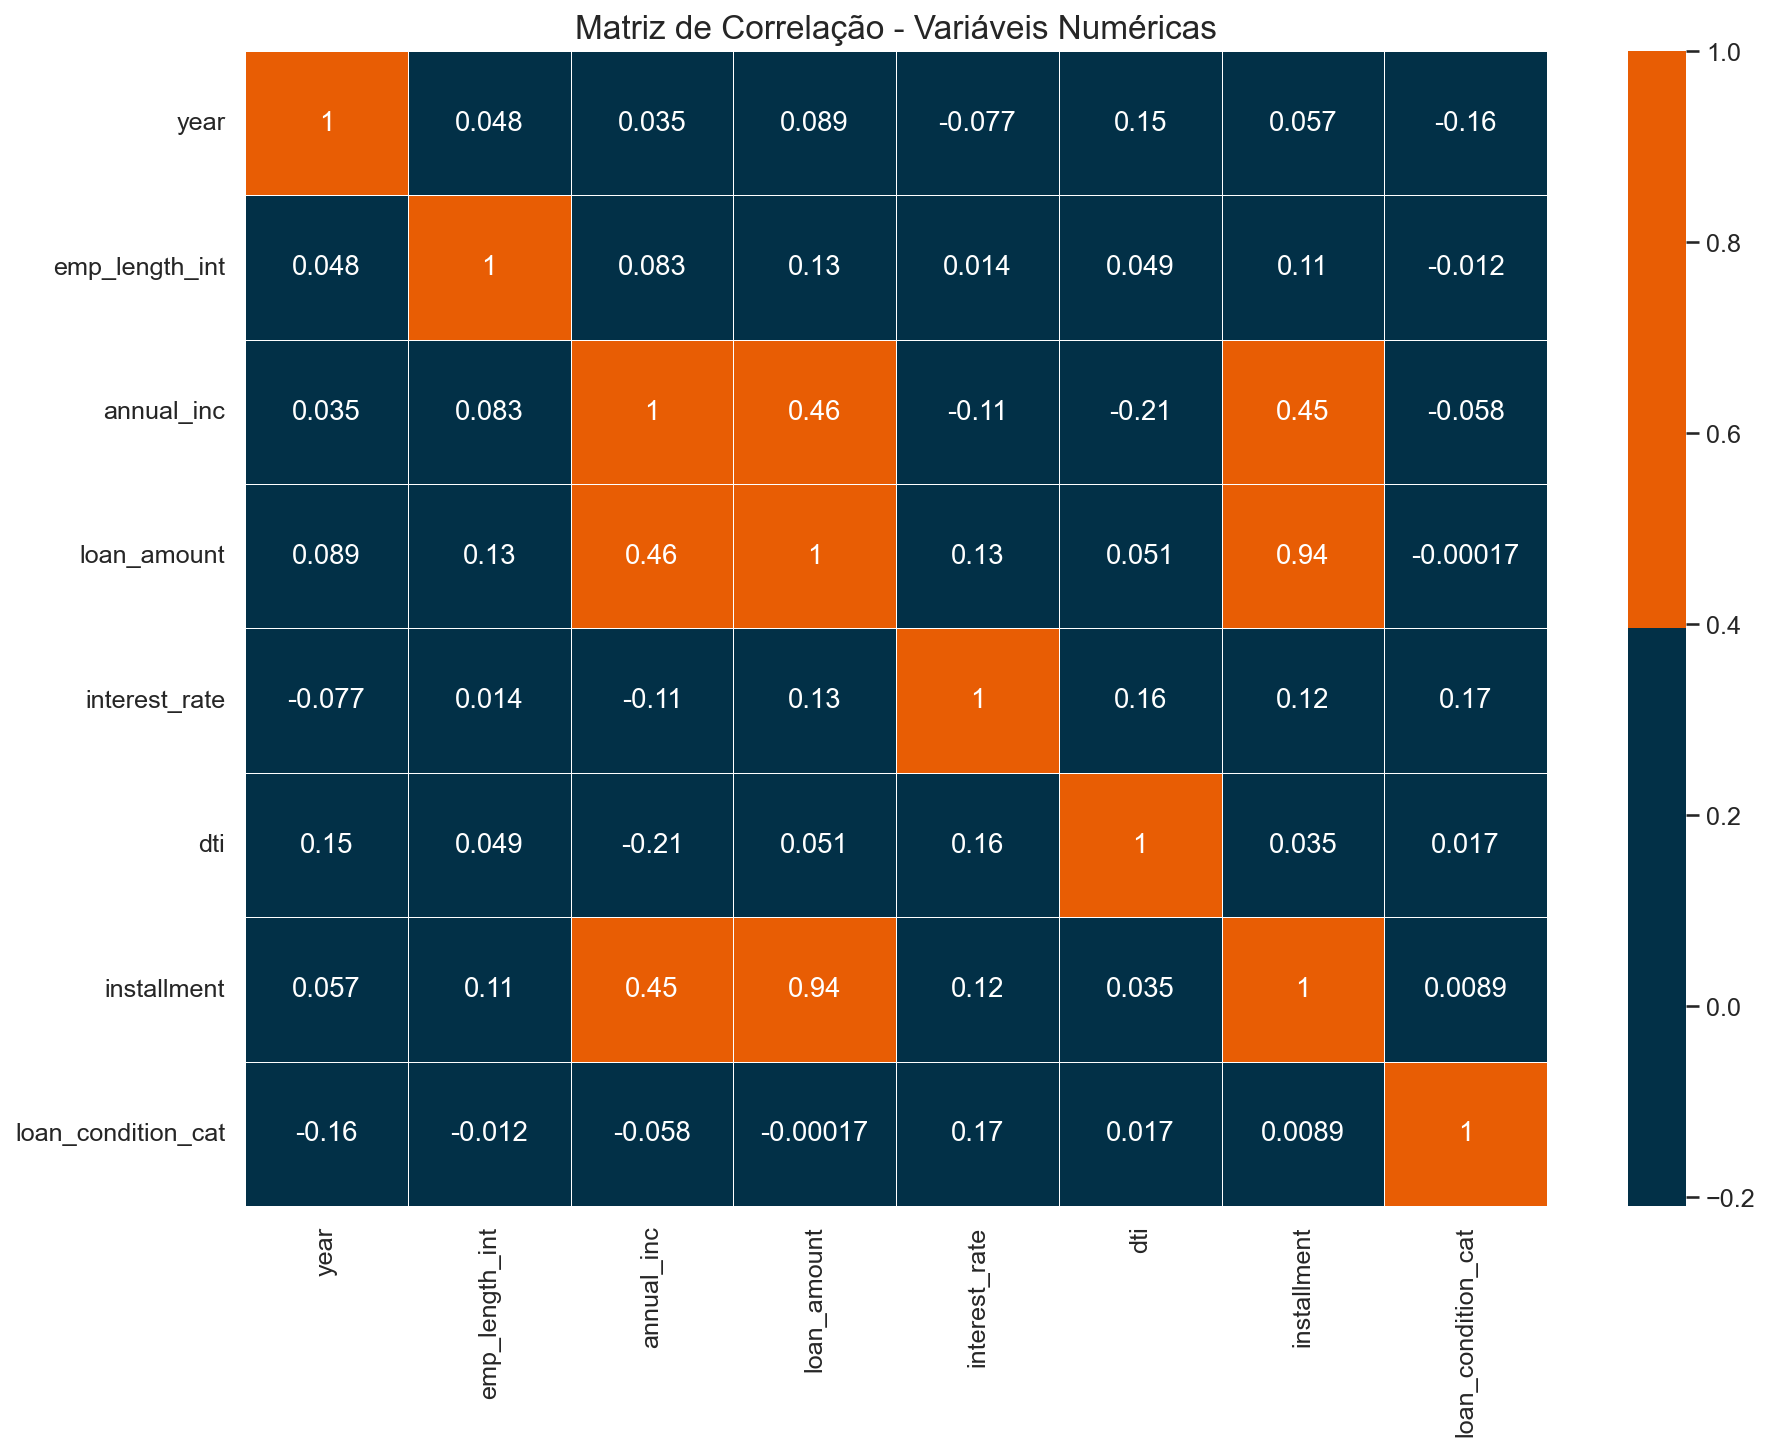

In [184]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    numericas.corr(),
    cmap=sns.color_palette([color_palette[0], color_palette[1]], as_cmap=True),
    annot=True,
    linewidths=0.3
)

plt.title("Matriz de Correlação - Variáveis Numéricas", fontsize=16)
plt.show()

A análise de correlação mostra relações esperadas entre variáveis financeiras, como loan_amount e installment, que apresentam forte correlação positiva (~0,94), já que parcelas maiores tendem a estar associadas a empréstimos maiores. A variável interest_rate apresentou a maior correlação com a variável alvo, sugerindo que clientes considerados mais arriscados recebem taxas maiores.

### Detecção de Outliers com Isolation Forest

Para uma detecção robusta e multivariada de outliers, vamos utilizar o algoritmo **Isolation Forest**, que é uma técnica baseada em árvores de decisão que isola observações incomuns com base em sua raridade estatística. Essa abordagem é eficaz em datasets com alta dimensionalidade e distribuições não normais.

Utilizamos a variavél numerica sem valores ausentes para treinar o modelo, e definimos uma contaminação de 5% para estimar a proporção de outliers no conjunto de dados.

In [62]:
numericas.dropna(inplace=True)

In [64]:
colunas_descartar = [col for col in numericas.columns if col.endswith("_d")]
numericas = numericas.drop(columns=colunas_descartar)

categoricas = [col for col in numericas.columns if "_cat" in col]
continuas = [col for col in numericas.columns if col not in categoricas]

if "outlier" in continuas:
    continuas.remove("outlier")

isoforest = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_labels = isoforest.fit_predict(numericas[continuas])

numericas["outlier"] = outlier_labels

outliers = numericas[numericas["outlier"] == -1]
normais = numericas[numericas["outlier"] == 1]

rare_threshold = 0.01
categorias_raras = {}

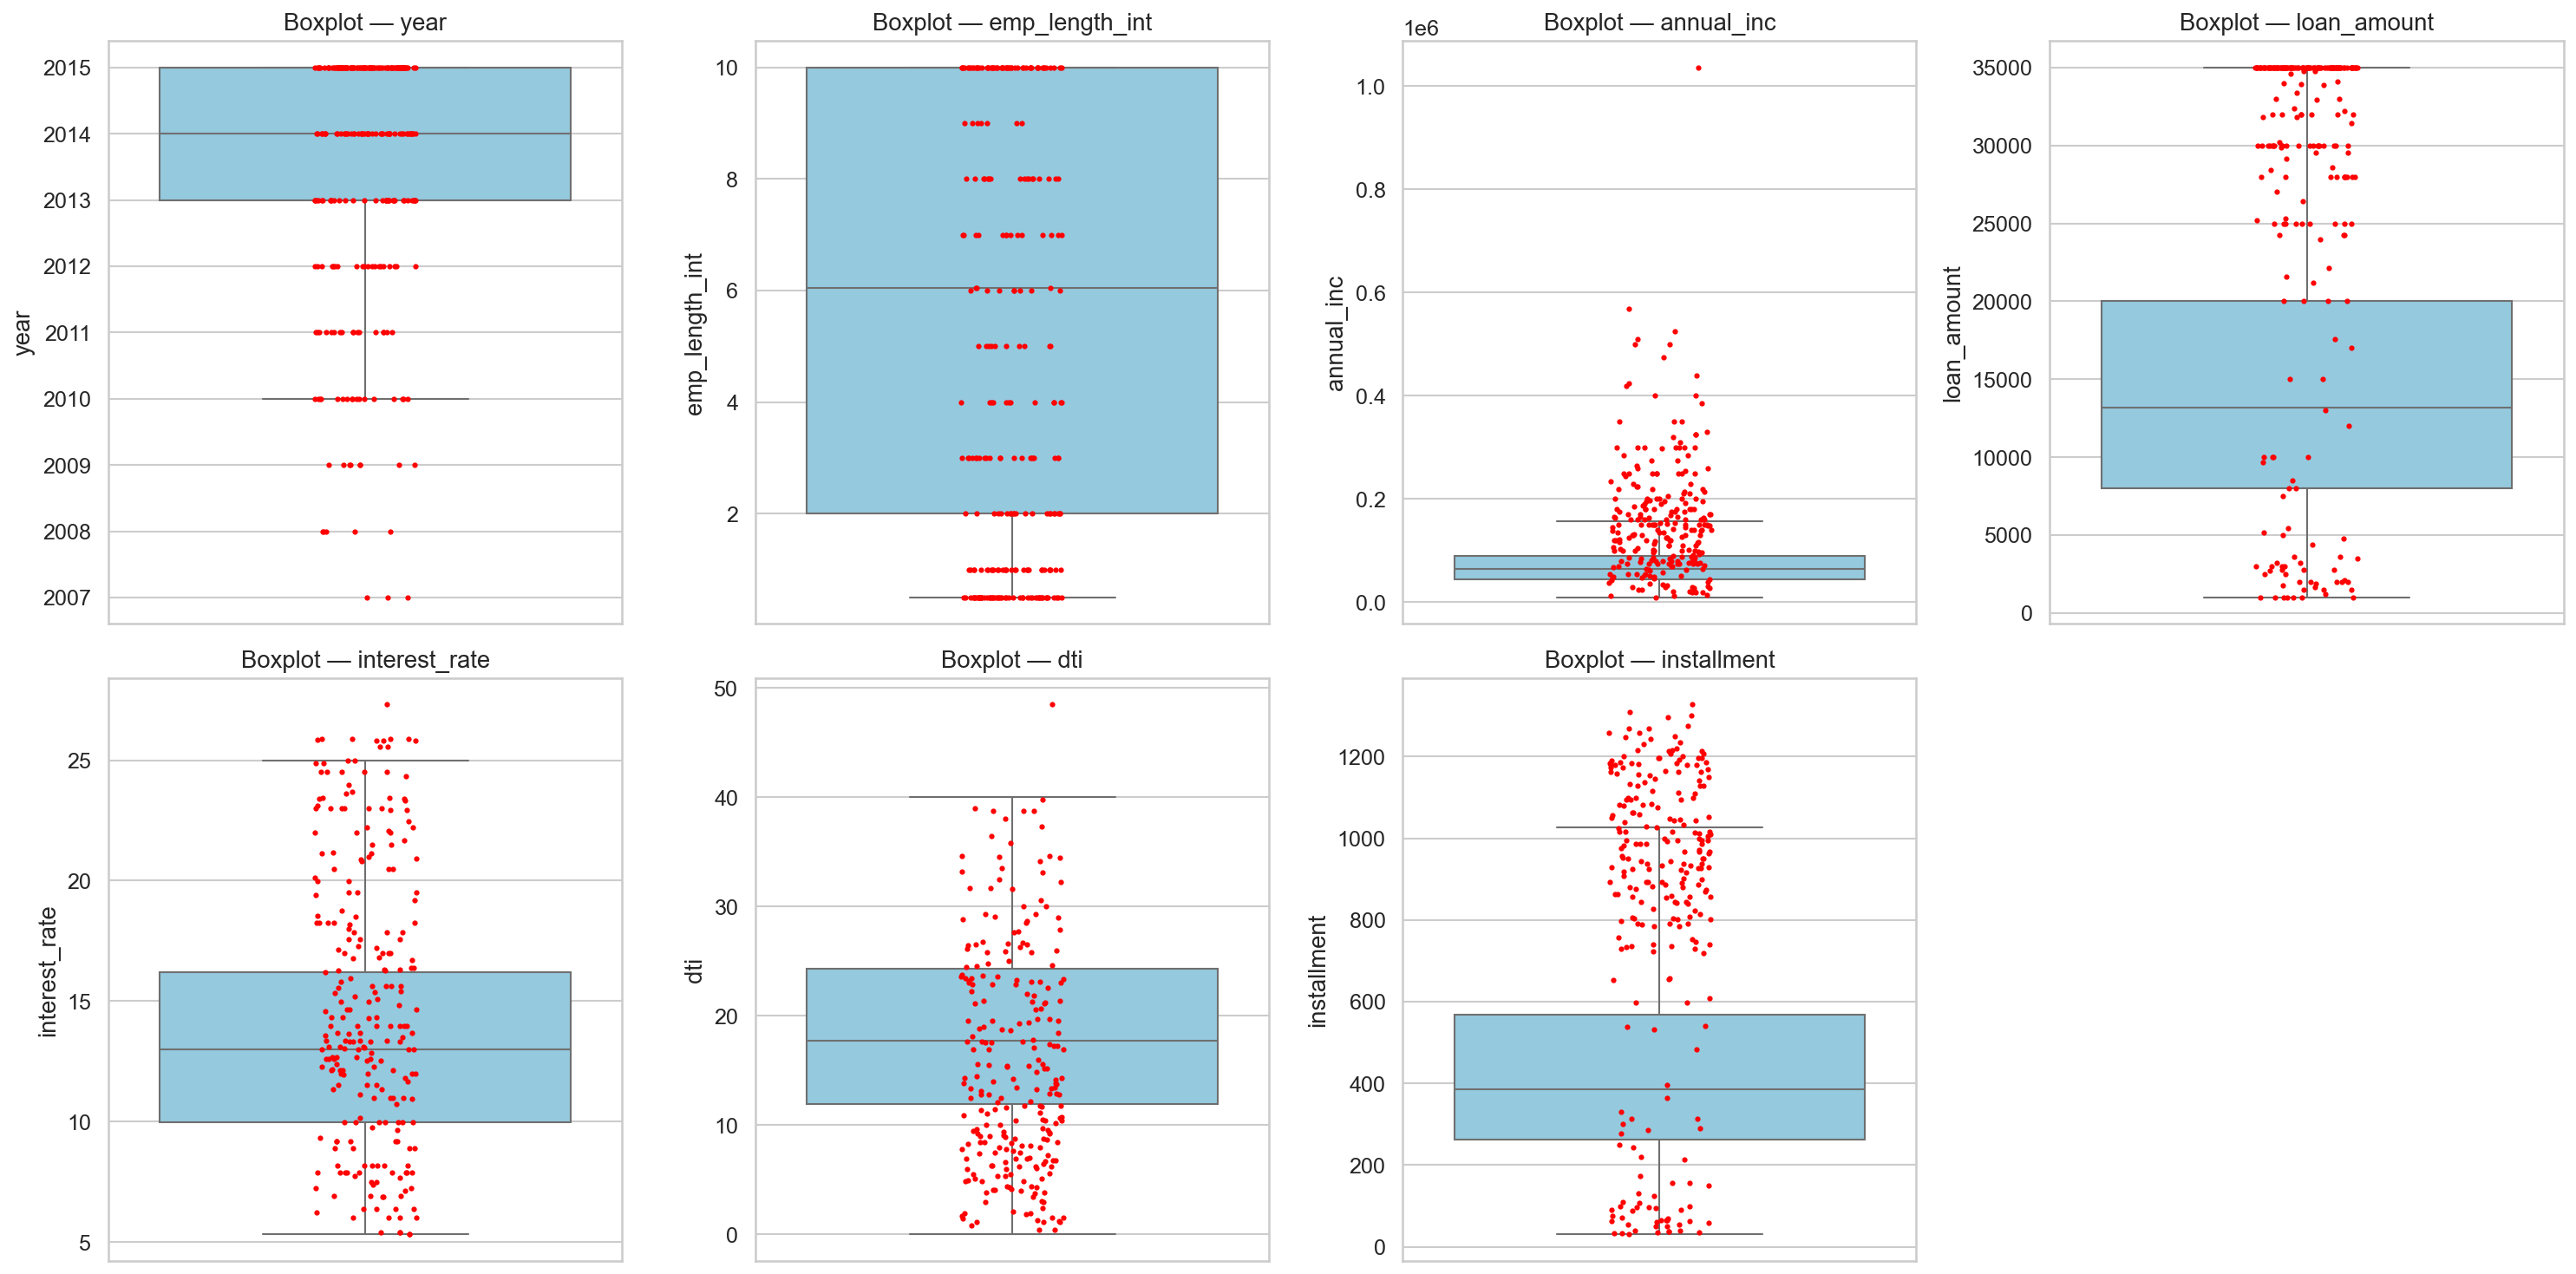

In [66]:
for col in categoricas:
    freq = numericas[col].value_counts(normalize=True)
    raras = freq[freq < rare_threshold].index.tolist()
    categorias_raras[col] = raras

cols_plot = continuas
n_cols = 4
n_rows = (len(cols_plot) + n_cols - 1) // n_cols

fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
ax = ax.flatten()

for i, col in enumerate(cols_plot):
    sns.boxplot(y=numericas[col], ax=ax[i], color='skyblue', showfliers=False)
    sns.stripplot(y=outliers[col], ax=ax[i], color='red', size=3, jitter=True)
    ax[i].set_title(f'Boxplot — {col}')
    if ax[i].get_legend():
        ax[i].get_legend().remove()

for j in range(len(cols_plot), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()


A análise dos boxplots mostra que várias variáveis financeiras apresentam grande dispersão e alguns valores extremos, representados pelos pontos destacados como possíveis outliers. Variáveis como annual_inc, loan_amount e installment apresentam maior amplitude de valores, indicando a existência de clientes com perfis financeiros bastante distintos do padrão predominante da base. A variável interest_rate também apresenta alguns valores elevados, o que pode estar relacionado a clientes classificados com maior risco de crédito. Já variáveis como year exibem menor variabilidade e comportamento mais regular. Apesar da presença desses valores extremos, optou-se por mantê-los no conjunto de dados, pois em problemas de risco de crédito eles podem representar casos reais e relevantes, como clientes de alta renda, empréstimos de valores elevados ou perfis financeiros incomuns. Removê-los poderia resultar em perda de informações importantes para o treinamento do modelo e reduzir sua capacidade de generalização.

Para melhorar a interpretação gráfica dos outliers detectados pelo Isolation Forest, aplicamos a técnica de Análise de Componentes Principais (PCA), reduzindo a dimensionalidade dos dados contínuos para apenas duas componentes principais. Esse procedimento permite projetar informações multidimensionais em um plano bidimensional, preservando ao máximo a variabilidade relevante e facilitando a distinção visual entre pontos normais e anômalos. Assim, após padronizar as variáveis numéricas, o PCA foi utilizado para gerar uma visualização clara, onde a dispersão dos dados e a separação dos outliers se tornam mais evidentes em um gráfico 2D.

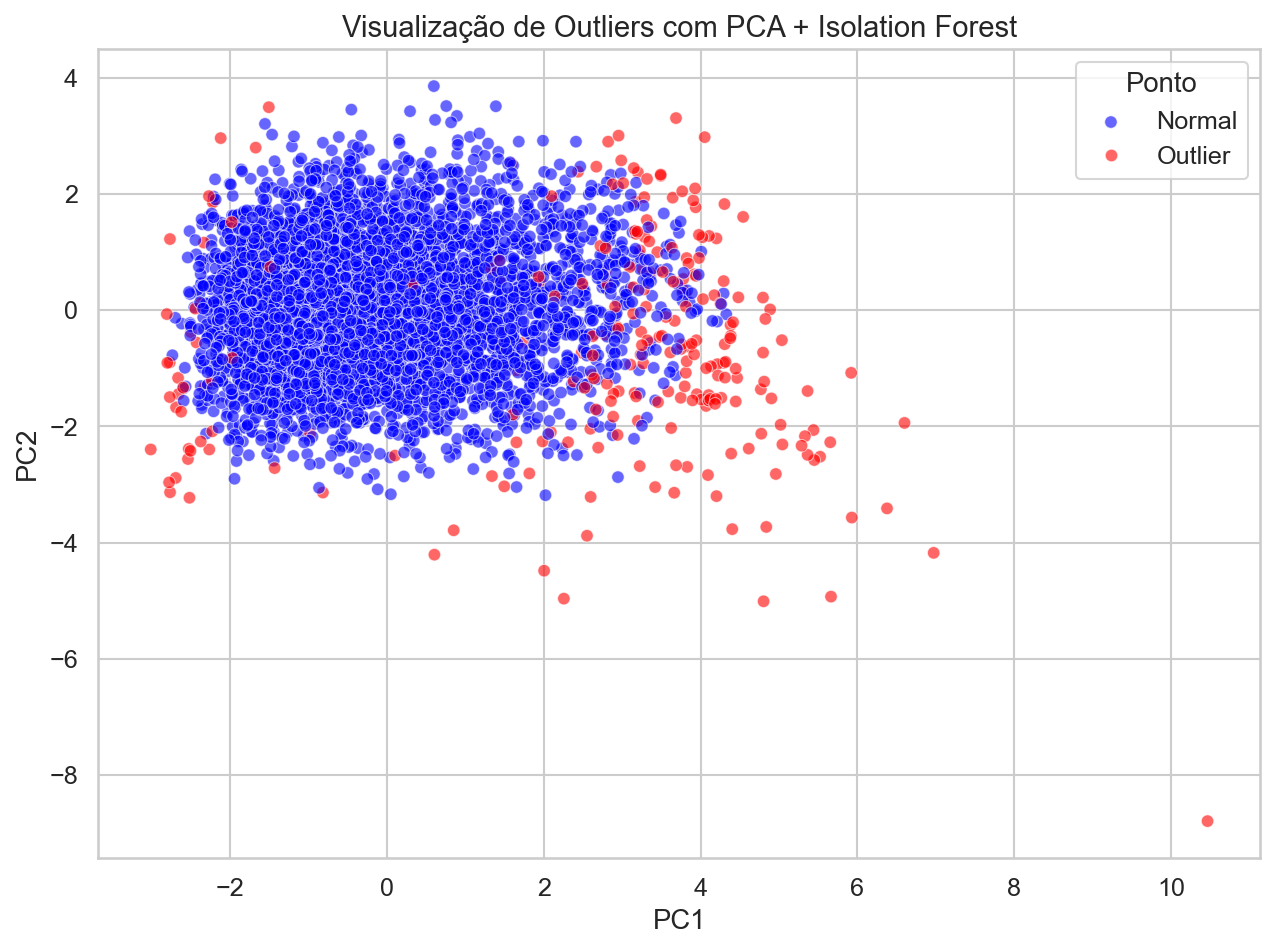

In [69]:
scaler = StandardScaler()
num_scaled = scaler.fit_transform(numericas[continuas])

# 2. Aplicar PCA para reduzir para 2 componentes
pca = PCA(n_components=2, random_state=42)
pca_comps = pca.fit_transform(num_scaled)

# 3. Criar um dataframe com as componentes + outliers
pca_df = pd.DataFrame({
    "PC1": pca_comps[:, 0],
    "PC2": pca_comps[:, 1],
    "outlier": numericas["outlier"]
})

# 4. Plot 2D
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="outlier",
    palette={1: "blue", -1: "red"},
    alpha=0.6,
)
plt.title("Visualização de Outliers com PCA + Isolation Forest", fontsize=14)
plt.legend(title="Ponto", labels=["Normal", "Outlier"])
plt.show()

O gráfico mostra os dados convertidos para duas dimensões usando PCA, e cada ponto representa um registro do conjunto de dados. Os pontos azuis são valores normais e os vermelhos são outliers detectados pelo Isolation Forest. Podemos ver que os pontos azuis ficam mais agrupados no centro, indicando que eles seguem um padrão comum. Já os pontos vermelhos aparecem mais espalhados e afastados desse grupo, o que mostra que eles têm comportamentos diferentes do restante e, por isso, foram marcados como anomalias.

## Conclusão da análise exploratória

A análise exploratória permitiu identificar características importantes do conjunto de dados e compreender possíveis fatores relacionados à inadimplência. Observou-se desbalanceamento entre classes, presença de valores ausentes, distribuições não normais, valores extremos e correlações relevantes entre algumas variáveis financeiras. Também foi verificado que nenhuma variável isolada apresenta forte poder discriminatório, sugerindo que a previsão da inadimplência depende da combinação de múltiplos fatores e relações não lineares. Essas observações orientarão as próximas etapas de pré-processamento e construção dos modelos preditivos.

---